# Partie 3 Amelioration - Architecture MS-SE-BiGRU-Attn

## 1. Objectif du notebook


- **Section A** : MS-SE-BiGRU-Attn sur S2 seul vs Partie 1 (MCTNet S2 only)
- **Section B** : MS-SE-BiGRU-Attn sur 5 configs avec covariables vs Partie 2 (MCTNet+Cov)





## 4. Plan du notebook

1. **Setup** : imports, config, architecture, helpers
2. **Section A** : MS-SE-BiGRU-Attn sur S2 seul, comparison vs Partie 1 
3. **Section B** : MS-SE-BiGRU-Attn sur 5 configs cov, comparison vs Partie 2


## Imports

In [2]:
import os, math, warnings
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, cohen_kappa_score, f1_score,
    confusion_matrix, classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'Device  : {torch.cuda.get_device_name(0)}')

PyTorch : 2.11.0+cpu
CUDA    : False


##  Configuration

In [3]:
PROCESSED_DIR = Path('data/processed')
MODEL_DIR     = Path('models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


N_BANDS_S2   = 10
N_DATES      = 36
BATCH_SIZE   = 32
LR           = 1e-3
EPOCHS       = 200
PATIENCE     = 30
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)


N_TRAIN_PER_CLASS_P1 = 240
N_VAL_PER_CLASS_P1   = 60


LABEL_MAP_AR = {1: 'Corn', 2: 'Cotton', 3: 'Rice', 5: 'Soybeans', 999: 'Others'}
AR_ORDER     = ['Corn', 'Cotton', 'Rice', 'Soybeans', 'Others']


LABEL_MAP_CA = {3: 'Rice', 36: 'Alfalfa', 69: 'Grapes', 75: 'Almonds',
                204: 'Pistachios', 999: 'Others'}
CA_ORDER     = ['Alfalfa', 'Almonds', 'Grapes', 'Others', 'Pistachios', 'Rice']

CONFIGS_P2 = ['S2_only', 'S2_climate', 'S2_soil', 'S2_topo', 'S2_all']

ALL_BANDS       = ['B02','B03','B04','B08','B05','B06','B07','B8A','B11','B12']
BAND_ORDER_WIDE = ['B11','B12','B2','B3','B4','B5','B6','B7','B8','B8A']

print(f'Device : {DEVICE}')
print(f'Configs Partie 2 : {CONFIGS_P2}')



Device : cpu
Configs Partie 2 : ['S2_only', 'S2_climate', 'S2_soil', 'S2_topo', 'S2_all']


##  Architecture — `MS-SE-BiGRU-Attn`



In [4]:
class SEBlock1D(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        r = max(channels // reduction, 4)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.fc  = nn.Sequential(
            nn.Linear(channels, r),
            nn.ReLU(inplace=True),
            nn.Linear(r, channels),
            nn.Sigmoid(),
        )
    def forward(self, x):
        s = self.gap(x).squeeze(-1)
        w = self.fc(s).unsqueeze(-1)
        return x * w


class MultiScaleConv1D(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=3):
        super().__init__()
        per = out_ch // 3
        rem = out_ch - 2 * per
        self.b1 = nn.Conv1d(in_ch, per, kernel, padding=(kernel-1)//2 * 1, dilation=1, bias=False)
        self.b2 = nn.Conv1d(in_ch, per, kernel, padding=(kernel-1)//2 * 2, dilation=2, bias=False)
        self.b3 = nn.Conv1d(in_ch, rem, kernel, padding=(kernel-1)//2 * 4, dilation=4, bias=False)
        self.bn = nn.BatchNorm1d(out_ch)
        self.act = nn.GELU()
    def forward(self, x):
        y = torch.cat([self.b1(x), self.b2(x), self.b3(x)], dim=1)
        return self.act(self.bn(y))


class AttentionPool(nn.Module):
    def __init__(self, hidden):
        super().__init__()
        self.score = nn.Linear(hidden, 1)
    def forward(self, x, mask=None):
        s = self.score(x).squeeze(-1)
        if mask is not None:
            s = s.masked_fill(mask == 0, float('-inf'))
        w = torch.softmax(s, dim=1).unsqueeze(-1)
        return (w * x).sum(dim=1)



class MS_SE_BiGRU_Attn(nn.Module):
    def __init__(self, n_bands, num_classes, hidden=64,
                 nhead=4, n_dates=36, dropout=0.35):
        super().__init__()
        self.n_dates = n_dates
        self.n_bands = n_bands

        self.ms_conv  = MultiScaleConv1D(n_bands, hidden, kernel=3)
        self.se       = SEBlock1D(hidden, reduction=4)
        self.drop_cnn = nn.Dropout(dropout)

        self.gru = nn.GRU(
            input_size=hidden,
            hidden_size=hidden // 2,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )

        self.attn = nn.MultiheadAttention(
            embed_dim=hidden, num_heads=nhead,
            dropout=dropout, batch_first=True,
        )
        self.norm1 = nn.LayerNorm(hidden)
        # FFN restaure (x2)
        self.ffn = nn.Sequential(
            nn.Linear(hidden, hidden * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden * 2, hidden),
        )
        self.norm2 = nn.LayerNorm(hidden)

        self.pool = AttentionPool(hidden)
        self.dropout_fc = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden, num_classes)

    def forward(self, x, mask=None):
        if x.dim() == 2:
            x = x.reshape(x.size(0), self.n_dates, self.n_bands)

        h = x.transpose(1, 2)
        h = self.ms_conv(h)
        h = self.se(h)
        h = self.drop_cnn(h)
        h = h.transpose(1, 2)

        h, _ = self.gru(h)

        pad_mask = (mask == 0) if mask is not None else None
        a, _ = self.attn(h, h, h, key_padding_mask=pad_mask, need_weights=False)
        h = self.norm1(h + a)
        h = self.norm2(h + self.ffn(h))

        z = self.pool(h, mask=mask)
        return self.fc(self.dropout_fc(z))


def build_model(n_bands, num_classes, device, hidden=64, dropout=0.35):
    model = MS_SE_BiGRU_Attn(
        n_bands=n_bands, num_classes=num_classes,
        hidden=hidden, dropout=dropout, n_dates=N_DATES,
    ).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    with torch.no_grad():
        x = torch.randn(2, N_DATES, n_bands).to(device)
        m = torch.ones(2, N_DATES).to(device)
        out = model(x, m)
        assert out.shape == (2, num_classes)
    print(f'  MS-SE-BiGRU-Attn BALANCED | bands={n_bands}  classes={num_classes}  params={n_params:,}  hidden={hidden}  dropout={dropout}')
    return model


print('=== Architecture BALANCED ===')
for nb_ in [10, 12, 13, 18]:
    build_model(nb_, 6, DEVICE)
print('OK')


=== Architecture BALANCED ===
  MS-SE-BiGRU-Attn BALANCED | bands=10  classes=6  params=56,919  hidden=64  dropout=0.35
  MS-SE-BiGRU-Attn BALANCED | bands=12  classes=6  params=57,303  hidden=64  dropout=0.35
  MS-SE-BiGRU-Attn BALANCED | bands=13  classes=6  params=57,495  hidden=64  dropout=0.35
  MS-SE-BiGRU-Attn BALANCED | bands=18  classes=6  params=58,455  hidden=64  dropout=0.35
OK


## Helpers d'entrainement

### Regularisation utilisee


- **Bruit gaussien** sigma=0.02 sur slots presents (comme Partie 1)
- **Time masking** : drop 3 slots aleatoires (comme Partie 1)
- **MixUp** alpha=0.3 : melange 2 samples (X,y) -> (X_mix, y_a, y_b)
- **Dropout** 0.35 dans CNN, BiGRU, MHSA
- **Label smoothing** 0.10 
- **Weight decay** 1e-3 (regul L2)
- **AdamW** + warmup 10 epochs + cosine annealing

### Pourquoi 2 train accuracies (`acc` vs `clean_acc`) ?

Pendant l'entrainement, on calcule **deux** accuracies sur le train :

| Metrique | Conditions | Sens |
|---|---|---|
| `acc` (with aug) | mode train, dropout actif, MixUp+bruit+timemask appliques | "ce que voit le modele pendant le backward" |
| `clean_acc` | mode eval, pas d'aug, pas de smoothing | "ce que le modele sait vraiment" |
| `val_acc` | mode eval, donnees jamais vues | "generalisation reelle" |

**Pour diagnostiquer l'overfitting** : comparer `clean_acc` vs `val_acc` 

`acc` (with aug) est tres biaisee a la baisse a cause de MixUp .

### Convention pour les plots

Dans `plot_history`, les **traits pleins** sont `clean_acc` et `val_acc` (les courbes "honnetes"). Le pointille `acc` (avec aug) est en reference informative seulement.

In [ ]:
def mixup_data(X, y, alpha=0.3, mask=None):
    if alpha <= 0:
        return X, y, y, 1.0, mask
    lam = np.random.beta(alpha, alpha)
    lam = max(lam, 1 - lam)
    idx = torch.randperm(X.size(0), device=X.device)
    X_mix = lam * X + (1 - lam) * X[idx]
    y_a, y_b = y, y[idx]
    mask_mix = mask if mask is None else (mask + mask[idx]).clamp(max=1.0)
    return X_mix, y_a, y_b, lam, mask_mix


def mixup_loss(criterion, out, y_a, y_b, lam):
    return lam * criterion(out, y_a) + (1 - lam) * criterion(out, y_b)


def add_gaussian_noise(X, sigma=0.02, mask=None):
    if sigma <= 0:
        return X
    noise = torch.randn_like(X) * sigma
    if mask is not None:
        nonzero = mask.unsqueeze(-1)
    else:
        nonzero = (X.abs().sum(dim=-1, keepdim=True) > 0).float()
    return X + noise * nonzero


def add_time_mask(X, mask, n_mask=3):
    if mask is None or n_mask <= 0:
        return X, mask
    X_aug = X.clone()
    mask_aug = mask.clone()
    B, T, _ = X.shape
    for b in range(B):
        present = mask[b].nonzero(as_tuple=True)[0]
        if len(present) > n_mask:
            drop = present[torch.randperm(len(present))[:n_mask]]
            X_aug[b, drop, :] = 0.0
            mask_aug[b, drop] = 0.0
    return X_aug, mask_aug


def make_loader(X, y, batch_size=BATCH_SIZE, shuffle=False, mask=None):
    tensors = [torch.from_numpy(X.astype('float32'))]
    if mask is not None:
        tensors.append(torch.from_numpy(mask.astype('float32')))
    tensors.append(torch.from_numpy(y.astype('int64')))
    ds = TensorDataset(*tensors)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=0)


def warmup_cosine(optimizer, total_epochs, warmup=10, eta_min_ratio=0.01):
    def f(ep):
        if ep < warmup:
            return (ep + 1) / warmup
        t = (ep - warmup) / max(total_epochs - warmup, 1)
        return eta_min_ratio + 0.5 * (1 - eta_min_ratio) * (1 + math.cos(math.pi * t))
    return optim.lr_scheduler.LambdaLR(optimizer, f)


def eval_clean(model, loader, device, use_mask=False):
    model.eval()
    crit = nn.CrossEntropyLoss()
    tl, tc, tt = 0., 0, 0
    with torch.no_grad():
        for batch in loader:
            if use_mask:
                X, m, y = batch
                X, m, y = X.to(device), m.to(device), y.to(device)
                out = model(X, m)
            else:
                X, y = batch
                X, y = X.to(device), y.to(device)
                out = model(X)
            tl += crit(out, y).item()
            tc += (out.argmax(1) == y).sum().item()
            tt += y.size(0)
    return tl / max(len(loader), 1), 100 * tc / max(tt, 1)


def hidden_for_n_bands(n_bands, base=64, nhead=4):
    h = max(base, base + (n_bands - 10) * 6)
    # Round UP au multiple de nhead
    return ((h + nhead - 1) // nhead) * nhead


def compute_class_weights(y, num_classes, device):
    counts = np.bincount(y, minlength=num_classes).astype('float32')
    w = counts.sum() / (num_classes * np.maximum(counts, 1))
    w = w / w.mean()
    return torch.tensor(w, dtype=torch.float32, device=device)


def train_model(model, tr_loader, va_loader, device, epochs=200,
                lr=1e-3, patience=30, label='', use_mixup=True,
                use_mask=False, label_smoothing=0.1, weight_decay=1e-3,
                noise_sigma=0.02, time_mask_n=3, eval_clean_every=1,
                class_weights=None):
    if class_weights is not None:
        crit_tr = nn.CrossEntropyLoss(label_smoothing=label_smoothing, weight=class_weights)
    else:
        crit_tr = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    crit_va  = nn.CrossEntropyLoss()
    opt      = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched    = warmup_cosine(opt, epochs, warmup=10)

    best_val_acc, best_state, best_ep, wait = 0.0, None, 0, 0
    hist = {'loss':[], 'acc':[], 'val_loss':[], 'val_acc':[],
            'clean_loss':[], 'clean_acc':[]}

    print(f'\n  [{label}] training... (epochs={epochs}, lr={lr}, wd={weight_decay}, cw={class_weights is not None})')
    for ep in range(epochs):
        model.train()
        tl, tc, tt = 0., 0, 0
        for batch in tr_loader:
            if use_mask:
                X, m, y = batch
                X, m, y = X.to(device), m.to(device), y.to(device)
            else:
                X, y = batch
                X, y = X.to(device), y.to(device)
                m = None

            X = add_gaussian_noise(X, sigma=noise_sigma, mask=m)
            if use_mask and time_mask_n > 0:
                X, m = add_time_mask(X, m, n_mask=time_mask_n)

            if use_mixup:
                X_in, y_a, y_b, lam, m_in = mixup_data(X, y, alpha=0.3, mask=m)
                opt.zero_grad()
                out  = model(X_in, m_in) if use_mask else model(X_in)
                loss = mixup_loss(crit_tr, out, y_a, y_b, lam)
            else:
                opt.zero_grad()
                out  = model(X, m) if use_mask else model(X)
                loss = crit_tr(out, y)

            if torch.isnan(loss) or torch.isinf(loss):
                continue
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            tl += loss.item()
            tc += (out.argmax(1) == y).sum().item()
            tt += y.size(0)
        sched.step()

        model.eval()
        vl, vc, vt = 0., 0, 0
        with torch.no_grad():
            for batch in va_loader:
                if use_mask:
                    X, m, y = batch
                    X, m, y = X.to(device), m.to(device), y.to(device)
                    out = model(X, m)
                else:
                    X, y = batch
                    X, y = X.to(device), y.to(device)
                    out = model(X)
                vl += crit_va(out, y).item()
                vc += (out.argmax(1) == y).sum().item()
                vt += y.size(0)

        ta_aug = 100 * tc / max(tt, 1)
        va_acc = 100 * vc / max(vt, 1)
        hist['loss'].append(tl / max(len(tr_loader), 1))
        hist['acc'].append(ta_aug)
        hist['val_loss'].append(vl / max(len(va_loader), 1))
        hist['val_acc'].append(va_acc)

        if (ep % eval_clean_every) == 0:
            cl_loss, cl_acc = eval_clean(model, tr_loader, device, use_mask=use_mask)
        hist['clean_loss'].append(cl_loss)
        hist['clean_acc'].append(cl_acc)

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}
            best_ep      = ep + 1
            wait         = 0
        else:
            wait += 1
            if wait >= patience:
                print(f'    early-stop ep={ep+1}  best={best_val_acc:.2f}% @ep{best_ep}')
                break

        if (ep + 1) % 25 == 0 or ep == 0:
            print(f'    [{ep+1:3d}/{epochs}] '
                  f'aug-loss={hist["loss"][-1]:.3f} aug-acc={ta_aug:.1f}%  '
                  f'| CLEAN-loss={cl_loss:.3f} CLEAN-acc={cl_acc:.1f}%  '
                  f'| val={hist["val_loss"][-1]:.3f} acc={va_acc:.1f}%  wait={wait}/{patience}')

    if best_state is not None:
        model.load_state_dict(best_state)
    print(f'    OK best val_acc={best_val_acc:.2f}% @ep{best_ep}')
    return model, hist


def evaluate_model(model, X_test, y_test, device, mask_test=None):
    model.eval()
    Xt = torch.from_numpy(X_test.astype('float32')).to(device)
    with torch.no_grad():
        if mask_test is not None:
            mt = torch.from_numpy(mask_test.astype('float32')).to(device)
            pred = model(Xt, mt).argmax(1).cpu().numpy()
        else:
            pred = model(Xt).argmax(1).cpu().numpy()
    return {
        'OA'   : 100 * accuracy_score(y_test, pred),
        'Kappa': cohen_kappa_score(y_test, pred),
        'F1'   : f1_score(y_test, pred, average='macro'),
        'pred' : pred,
        'y_true': y_test,
    }

print('Helpers + hidden_for_n_bands + compute_class_weights')


Helpers + hidden_for_n_bands + compute_class_weights


---
# Section A — Reproduction Partie 1 



In [ ]:
def load_part1_data(csv_path, label, label_map,
                    n_train=N_TRAIN_PER_CLASS_P1, n_val=N_VAL_PER_CLASS_P1,
                    seed=RANDOM_STATE):
    print(f'\n══ {label} — chargement Partie 1 ══')
    df = pd.read_csv(csv_path)
    feat_cols = [c for c in df.columns if c != 'label']
    def sort_key(c):
        b, t = c.rsplit('_t', 1)
        return (BAND_ORDER_WIDE.index(b), int(t))
    feat_cols = sorted(feat_cols, key=sort_key)
    assert len(feat_cols) == 360

    X_raw = df[feat_cols].values.astype('float32')   # (N, 360) ordre alphab.

   
    band_map = {'B02':'B2','B03':'B3','B04':'B4','B05':'B5','B06':'B6',
                'B07':'B7','B08':'B8','B8A':'B8A','B11':'B11','B12':'B12'}
    perm = []
    for paper_band in ALL_BANDS:
        bi = BAND_ORDER_WIDE.index(band_map[paper_band])
        for t in range(N_DATES):
            perm.append(bi * N_DATES + t)
    X = X_raw[:, perm]
    N = X.shape[0]
    X = X.reshape(N, N_BANDS_S2, N_DATES).transpose(0, 2, 1)   # (N, 36, 10)

   
    mask = (np.abs(X).sum(axis=-1) > 0).astype('float32')

   
    raw = df['label'].values
    str_y = np.array([label_map.get(int(v), str(int(v))) for v in raw])
    le = LabelEncoder()
    y = le.fit_transform(str_y)

    
    rng = np.random.default_rng(seed)
    idx_tr, idx_va, idx_te = [], [], []
    rows = []
    for c in range(len(le.classes_)):
        idx_c = np.where(y == c)[0]
        rng.shuffle(idx_c)
        n_total = len(idx_c)
        n_tr    = min(n_train, n_total)
        n_v     = min(n_val, n_total - n_tr)
        idx_tr.extend(idx_c[:n_tr])
        idx_va.extend(idx_c[n_tr:n_tr + n_v])
        idx_te.extend(idx_c[n_tr + n_v:])
        rows.append({'Classe': le.classes_[c], 'Train': n_tr, 'Val': n_v,
                     'Test': n_total - n_tr - n_v})
    idx_tr, idx_va, idx_te = map(np.array, (idx_tr, idx_va, idx_te))

    
    Xf = X.reshape(N, -1)
    sc = StandardScaler()
    Xs = Xf.copy()
    Xs[idx_tr] = sc.fit_transform(Xf[idx_tr])
    Xs[idx_va] = sc.transform(Xf[idx_va])
    Xs[idx_te] = sc.transform(Xf[idx_te])
    Xs[Xf == 0] = 0.0
    Xs = Xs.reshape(N, N_DATES, N_BANDS_S2)

    df_t = pd.DataFrame(rows)
    df_t.loc[len(df_t)] = {'Classe':'TOTAL', 'Train':df_t['Train'].sum(),
                            'Val':df_t['Val'].sum(), 'Test':df_t['Test'].sum()}
    print(df_t.to_string(index=False))

    return {
        'X_train': Xs[idx_tr], 'm_train': mask[idx_tr], 'y_train': y[idx_tr],
        'X_val'  : Xs[idx_va], 'm_val'  : mask[idx_va], 'y_val'  : y[idx_va],
        'X_test' : Xs[idx_te], 'm_test' : mask[idx_te], 'y_test' : y[idx_te],
        'le': le, 'scaler': sc,
    }

In [7]:
# CALIFORNIA 
data_CA_p1 = load_part1_data(
    PROCESSED_DIR / 'CALIFORNIA_10000x360.csv',
    label='CALIFORNIA', label_map=LABEL_MAP_CA,
)

tr_loader = make_loader(data_CA_p1['X_train'], data_CA_p1['y_train'],
                        mask=data_CA_p1['m_train'], shuffle=True)
va_loader = make_loader(data_CA_p1['X_val'], data_CA_p1['y_val'],
                        mask=data_CA_p1['m_val'])

model_CA_p1 = build_model(
    n_bands=N_BANDS_S2, num_classes=len(data_CA_p1['le'].classes_),
    device=DEVICE, hidden=64, dropout=0.35,
)
model_CA_p1, hist_CA_p1 = train_model(
    model_CA_p1, tr_loader, va_loader, DEVICE,
    label='CALIFORNIA-P1', use_mixup=True, use_mask=True,
)
res_CA_p1 = evaluate_model(
    model_CA_p1, data_CA_p1['X_test'], data_CA_p1['y_test'],
    DEVICE, mask_test=data_CA_p1['m_test'],
)
print(f"\n  [CA-P1] OA={res_CA_p1['OA']:.2f}%  Kappa={res_CA_p1['Kappa']:.4f}  Macro-F1={res_CA_p1['F1']:.4f}")



══ CALIFORNIA — chargement Partie 1 ══
    Classe  Train  Val  Test
   Alfalfa    240   60   674
   Almonds    240   60   483
    Grapes    240   60  1754
    Others    240   60  3212
Pistachios    240   60   340
      Rice    240   60  1737
     TOTAL   1440  360  8200
  MS-SE-BiGRU-Attn BALANCED | bands=10  classes=6  params=56,919  hidden=64  dropout=0.35

  [CALIFORNIA-P1] training... (epochs=200, lr=0.001, wd=0.001, cw=False)
    [  1/200] aug-loss=1.772 aug-acc=26.2%  | CLEAN-loss=1.562 CLEAN-acc=47.5%  | val=1.571 acc=47.5%  wait=0/30
    [ 25/200] aug-loss=1.111 aug-acc=72.6%  | CLEAN-loss=0.587 CLEAN-acc=81.7%  | val=0.661 acc=75.0%  wait=4/30
    [ 50/200] aug-loss=0.976 aug-acc=82.6%  | CLEAN-loss=0.426 CLEAN-acc=88.1%  | val=0.584 acc=80.6%  wait=5/30
    early-stop ep=75  best=81.94% @ep45
    OK best val_acc=81.94% @ep45

  [CA-P1] OA=83.13%  Kappa=0.7790  Macro-F1=0.7543


In [8]:
# ARKANSAS - Partie 1 
data_AR_p1 = load_part1_data(
    PROCESSED_DIR / 'ARKANSAS_10000x360.csv',
    label='ARKANSAS', label_map=LABEL_MAP_AR,
)

tr_loader = make_loader(data_AR_p1['X_train'], data_AR_p1['y_train'],
                        mask=data_AR_p1['m_train'], shuffle=True)
va_loader = make_loader(data_AR_p1['X_val'], data_AR_p1['y_val'],
                        mask=data_AR_p1['m_val'])

model_AR_p1 = build_model(
    n_bands=N_BANDS_S2, num_classes=len(data_AR_p1['le'].classes_),
    device=DEVICE, hidden=64, dropout=0.35,
)
model_AR_p1, hist_AR_p1 = train_model(
    model_AR_p1, tr_loader, va_loader, DEVICE,
    label='ARKANSAS-P1', use_mixup=True, use_mask=True,
)
res_AR_p1 = evaluate_model(
    model_AR_p1, data_AR_p1['X_test'], data_AR_p1['y_test'],
    DEVICE, mask_test=data_AR_p1['m_test'],
)
print(f"\n  [AR-P1] OA={res_AR_p1['OA']:.2f}%  Kappa={res_AR_p1['Kappa']:.4f}  Macro-F1={res_AR_p1['F1']:.4f}")



══ ARKANSAS — chargement Partie 1 ══
  Classe  Train  Val  Test
    Corn    240   60  1222
  Cotton    240   60   462
  Others    240   60   316
    Rice    240   60  2123
Soybeans    240   60  4377
   TOTAL   1200  300  8500
  MS-SE-BiGRU-Attn BALANCED | bands=10  classes=5  params=56,854  hidden=64  dropout=0.35

  [ARKANSAS-P1] training... (epochs=200, lr=0.001, wd=0.001, cw=False)
    [  1/200] aug-loss=1.646 aug-acc=23.0%  | CLEAN-loss=1.472 CLEAN-acc=42.2%  | val=1.472 acc=47.0%  wait=0/30
    [ 25/200] aug-loss=0.813 aug-acc=87.0%  | CLEAN-loss=0.331 CLEAN-acc=92.2%  | val=0.431 acc=88.7%  wait=0/30
    [ 50/200] aug-loss=0.839 aug-acc=88.1%  | CLEAN-loss=0.232 CLEAN-acc=95.9%  | val=0.422 acc=88.3%  wait=2/30
    [ 75/200] aug-loss=0.880 aug-acc=86.8%  | CLEAN-loss=0.246 CLEAN-acc=98.0%  | val=0.439 acc=88.7%  wait=27/30
    early-stop ep=78  best=90.67% @ep48
    OK best val_acc=90.67% @ep48

  [AR-P1] OA=89.65%  Kappa=0.8454  Macro-F1=0.8418


### Visualisation Section A 

#### Courbes loss/accuracy

- **Trait plein rouge/vert** : `clean_acc` (train propre, mode eval) -> performance reelle du modele sur train
- **Trait plein bleu** : `val_acc` (validation) -> generalisation sur donnees non vues
- **Trait pointille** : `acc` (avec aug+MixUp) -> en info seulement, **biaise**


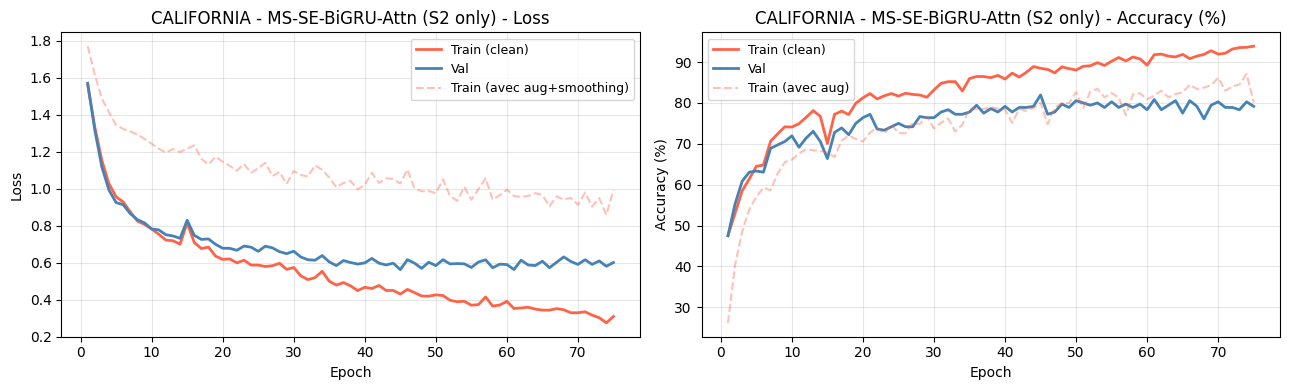

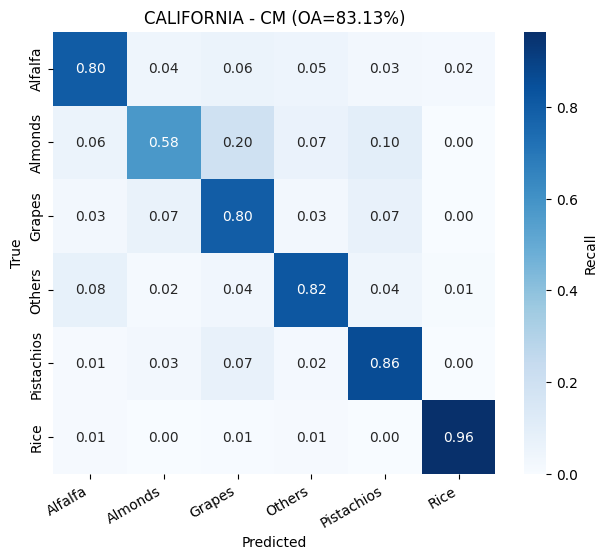


- CLASSIFICATION REPORT California -
              precision    recall  f1-score   support

     Alfalfa      0.604     0.800     0.688       674
     Almonds      0.567     0.580     0.573       483
      Grapes      0.831     0.796     0.813      1754
      Others      0.948     0.820     0.880      3212
  Pistachios      0.467     0.862     0.605       340
        Rice      0.970     0.964     0.967      1737

    accuracy                          0.831      8200
   macro avg      0.731     0.804     0.754      8200
weighted avg      0.857     0.831     0.839      8200



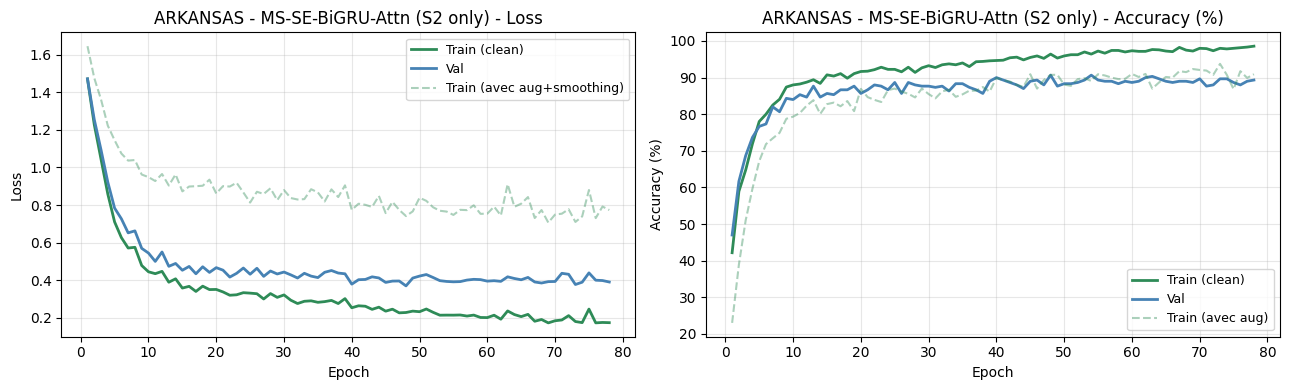

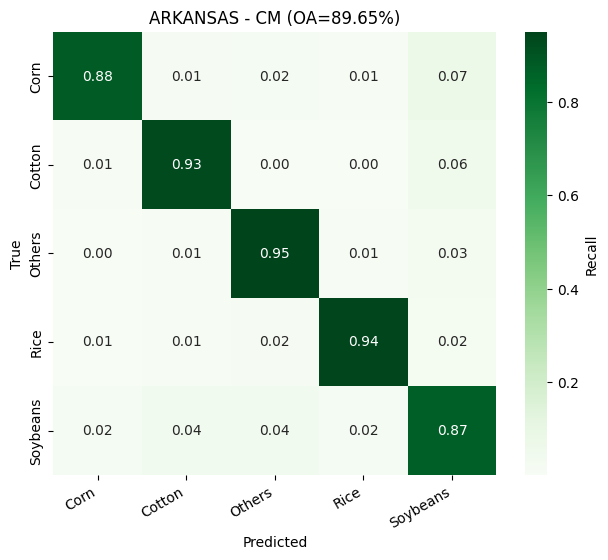


- CLASSIFICATION REPORT Arkansas -
              precision    recall  f1-score   support

        Corn      0.910     0.881     0.895      1222
      Cotton      0.664     0.931     0.775       462
      Others      0.534     0.949     0.683       316
        Rice      0.946     0.943     0.945      2123
    Soybeans      0.955     0.870     0.911      4377

    accuracy                          0.896      8500
   macro avg      0.802     0.915     0.842      8500
weighted avg      0.915     0.896     0.901      8500



In [9]:
def plot_history(hist, label, color='tomato'):
    """Trace les courbes propres : clean train (mode eval, sans aug) vs val.
       Loss/Acc avec aug+smoothing/MixUp en pointille pour info."""
    eps = range(1, len(hist['loss']) + 1)
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))

    # LOSS
    ax[0].plot(eps, hist['clean_loss'], color=color, label='Train (clean)', linewidth=2)
    ax[0].plot(eps, hist['val_loss'],   color='steelblue', label='Val', linewidth=2)
    ax[0].plot(eps, hist['loss'], color=color, linestyle='--', alpha=0.4,
               label='Train (avec aug+smoothing)')
    ax[0].set_title(f'{label} - Loss')
    ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Loss')
    ax[0].legend(fontsize=9); ax[0].grid(alpha=0.3)

    # ACCURACY
    ax[1].plot(eps, hist['clean_acc'], color=color, label='Train (clean)', linewidth=2)
    ax[1].plot(eps, hist['val_acc'],   color='steelblue', label='Val', linewidth=2)
    ax[1].plot(eps, hist['acc'], color=color, linestyle='--', alpha=0.4,
               label='Train (avec aug)')
    ax[1].set_title(f'{label} - Accuracy (%)')
    ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('Accuracy (%)')
    ax[1].legend(fontsize=9); ax[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()


def plot_cm(y_true, y_pred, classes, title, cmap='Blues'):
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap=cmap, xticklabels=classes,
                yticklabels=classes, square=True, cbar_kws={'label':'Recall'}, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(title); plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()


# California
plot_history(hist_CA_p1, 'CALIFORNIA - MS-SE-BiGRU-Attn (S2 only)')
plot_cm(res_CA_p1['y_true'], res_CA_p1['pred'], list(data_CA_p1['le'].classes_),
        title=f'CALIFORNIA - CM (OA={res_CA_p1["OA"]:.2f}%)')
print('\n- CLASSIFICATION REPORT California -')
print(classification_report(res_CA_p1['y_true'], res_CA_p1['pred'],
                            target_names=list(data_CA_p1['le'].classes_), digits=3))

# Arkansas
plot_history(hist_AR_p1, 'ARKANSAS - MS-SE-BiGRU-Attn (S2 only)', color='seagreen')
plot_cm(res_AR_p1['y_true'], res_AR_p1['pred'], list(data_AR_p1['le'].classes_),
        title=f'ARKANSAS - CM (OA={res_AR_p1["OA"]:.2f}%)', cmap='Greens')
print('\n- CLASSIFICATION REPORT Arkansas -')
print(classification_report(res_AR_p1['y_true'], res_AR_p1['pred'],
                            target_names=list(data_AR_p1['le'].classes_), digits=3))


### Heatmap d'importance des features - Section A (style Fig. 9, Wang et al. 2021)

#### A quoi sert cette visualisation ?

La heatmap permet de **comprendre ce que le modele apprend**. Pour chaque culture, on visualise quelles **bandes spectrales** et quelles **dates de l'annee** sont importantes pour la classifier.

C'est un outil d'**interpretabilite** : sans lui, le modele est une boite noire qui sort un OA = 86% sans qu'on sache pourquoi. Avec, on peut :
- **Valider** que le modele apprend des patterns physiquement coherents (phenologie reelle des cultures)
- **Detecter** s'il apprend du bruit (importance dispersee sans structure)
- **Comparer** comment differentes cultures sont distinguees
- **Justifier** scientifiquement les performances en soutenance

#### Methode : Gradient x Input (Saliency Map)

C'est la methode la plus utilisee pour l'attribution en deep learning :

1. **Forward** : on passe un pixel test dans le modele -> `logits = model(x, mask)`
2. **Backward** : on calcule la derivee partielle du logit de la classe par rapport a chaque feature d'entree -> `gradient = d(logit_classe) / dx`
3. **Saliency** : on multiplie par la valeur d'entree -> `importance = |gradient × x|`
   - Le **gradient** indique a quel point ce feature **influence** la prediction
   - La **valeur** indique a quel point ce feature est **present** dans le pixel
   - Le produit = combien chaque feature **contribue effectivement** a la prediction
4. **Aggregation** : on moyenne sur ~50 pixels de la meme classe -> pattern robuste

#### Comment lire la heatmap

| Element | Signification |
|---------|---------------|
| **Axe Y (bandes)** | 10 bandes Sentinel-2 du bas vers le haut : Blue, Green, Red, Red Edge 1-4, NIR, SWIR 1-2 |
| **Axe X (Day of Year)** | 36 dates dans l'annee (1 a 360 jours) |
| **Rouge / chaud** | Forte importance - feature crucial pour distinguer cette culture |
| **Bleu / froid** | Faible importance - feature ignore |
| **Ligne pointillee blanche (DOY=180)** | Mi-annee, repere phenologique (juillet = peak vegetation pour hemisphere nord) |

#### Patterns phenologiques attendus

Si le modele est physiquement valide, on s'attend a observer :

- **Cultures annuelles (Corn, Soybeans, Cotton)** : pic d'importance NIR/Red Edge en **juillet-aout** (peak NDVI - vegetation maximale)
- **Rice** : forte importance des SWIR (B11, B12) en debut de saison (inondation des rizieres -> SWIR sensible a l'eau)
- **Cultures peremes (Almonds, Pistachios, Grapes)** : pattern plus diffus sur l'annee (feuillage persistant)
- **Alfalfa** : multiples pics (foin coupe 3-5 fois/an -> plusieurs cycles de regrowth)
- **Others** : pattern bruite ou pic en saison non-typique

Si on voit ces patterns -> le modele apprend de la phenologie reelle, pas du bruit. **C'est un argument fort pour le rapport**.

Calcul saliency CALIFORNIA...
  Sauvegarde : data\processed\feature_importance_CA_sectionA.png


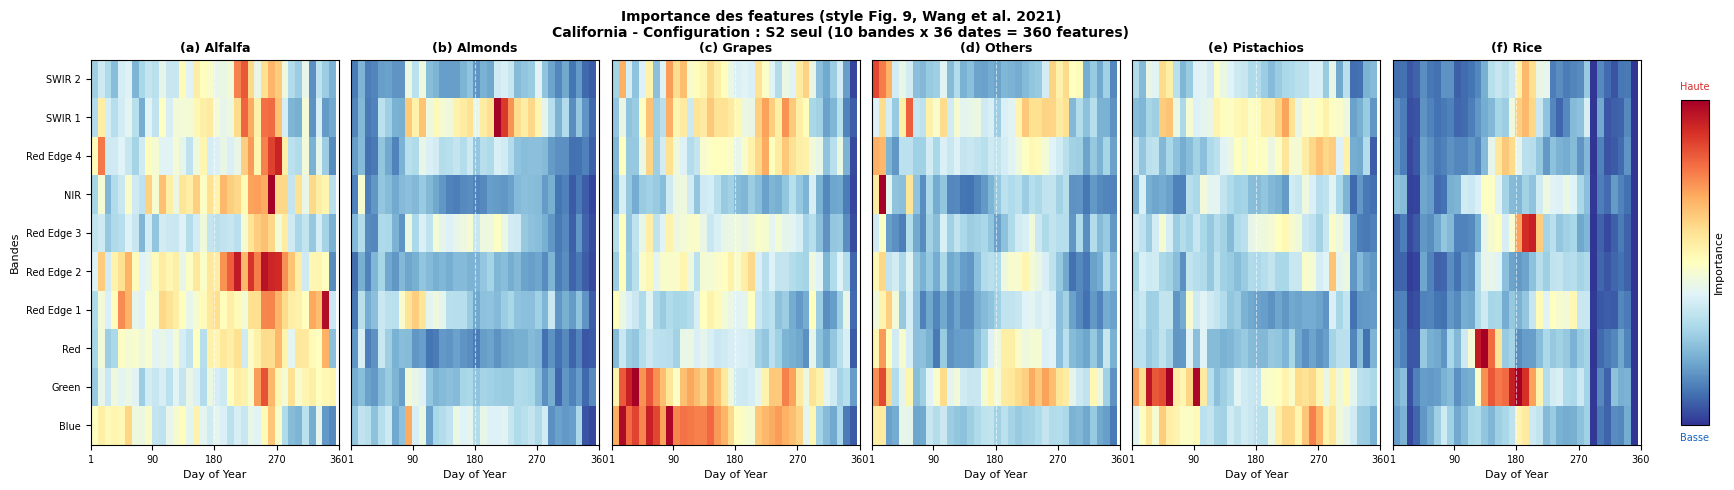

Calcul saliency ARKANSAS...
  Sauvegarde : data\processed\feature_importance_AR_sectionA.png


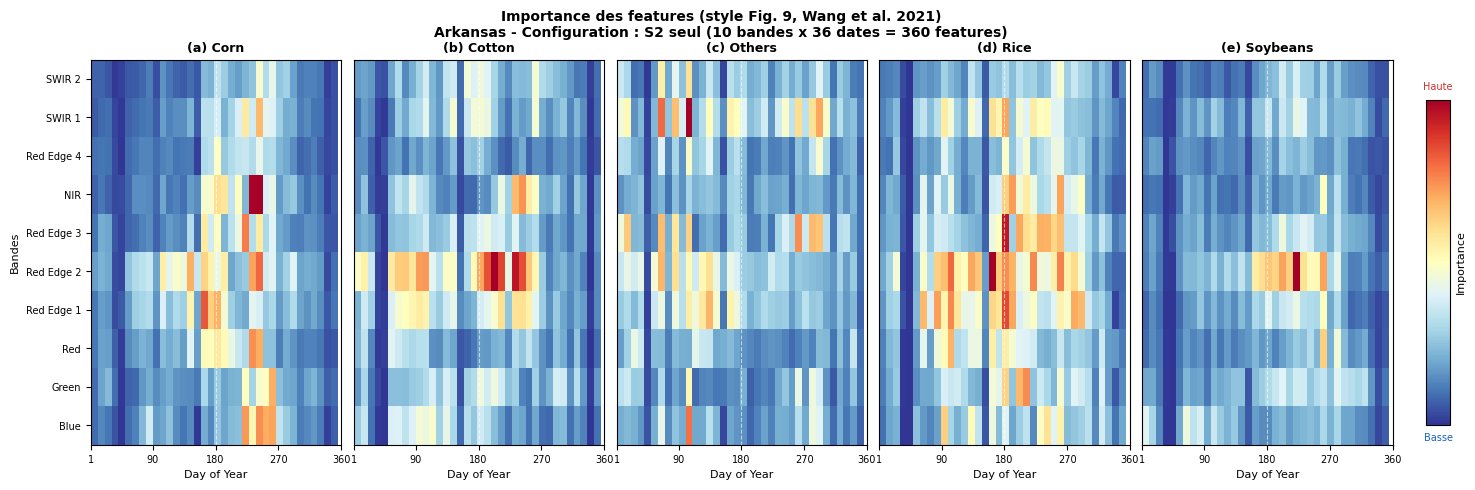

In [ ]:
import torch.nn.functional as F

S2_BAND_NAMES = ['Blue', 'Green', 'Red',
                 'Red Edge 1', 'Red Edge 2', 'Red Edge 3',
                 'NIR', 'Red Edge 4', 'SWIR 1', 'SWIR 2']
# Ordre = ALL_BANDS = ['B02','B03','B04','B08','B05','B06','B07','B8A','B11','B12']
# Note: ce mapping est juste cosmetique (les noms affiches en Y dans le plot).


def compute_saliency_per_class(model, X_test, m_test, y_test, le, device,
                                n_samples_per_class=50):
    """Calcule l'importance des features (Gradient x Input) par classe.
       Retourne un dict {class_name : np.array (N_DATES, n_bands)}."""
    model.eval()
    saliency_dict = {}

    for cls_idx, cls_name in enumerate(le.classes_):
        sel = (y_test == cls_idx)
        X_cls = X_test[sel][:n_samples_per_class]   # (Nc, T, C)
        m_cls = m_test[sel][:n_samples_per_class]
        if len(X_cls) == 0:
            continue

        T, C = X_cls.shape[1], X_cls.shape[2]
        accum = np.zeros((T, C), dtype=np.float32)

        for i in range(len(X_cls)):
            x = torch.from_numpy(X_cls[i:i+1].astype('float32')).to(device)
            m = torch.from_numpy(m_cls[i:i+1].astype('float32')).to(device)
            x.requires_grad_(True)

            logits = model(x, m)
            score  = logits[0, cls_idx]
            model.zero_grad()
            score.backward()

            grad = x.grad.detach().cpu().numpy()[0]   # (T, C)
            inp  = X_cls[i]                           # (T, C)
            sal  = np.abs(grad * inp)
            sal /= (sal.max() + 1e-8)
            accum += sal

        saliency_dict[cls_name] = accum / max(len(X_cls), 1)

    return saliency_dict


def plot_feature_importance(saliency_dict, region_label, n_bands=10, save_path=None):
    """Reproduit Fig. 9 """
    classes = list(saliency_dict.keys())
    n_cls   = len(classes)
    band_names = S2_BAND_NAMES[:n_bands]
    doy_axis = [int(i * 365 / 36) + 1 for i in range(36)]

    fig_h = max(4.0, n_bands * 0.35 + 1.5)
    fig, axes = plt.subplots(1, n_cls,
                              figsize=(3.2 * n_cls + 0.8, fig_h),
                              squeeze=False)
    fig.suptitle(
        f'Importance des features (style Fig. 9, Wang et al. 2021)\n'
        f'{region_label} - Configuration : S2 seul ({n_bands} bandes x 36 dates = {n_bands*36} features)',
        fontsize=10, fontweight='bold'
    )

    im_ref = None
    for j, cls_name in enumerate(classes):
        ax  = axes[0, j]
        cam = saliency_dict[cls_name]      # (T=36, C=n_bands)
        cam_T = cam.T                      # (n_bands, 36) pour Y=bandes, X=dates

        im = ax.imshow(
            cam_T, aspect='auto', cmap='RdYlBu_r',
            vmin=0, vmax=cam_T.max(),
            extent=[doy_axis[0], doy_axis[-1], -0.5, n_bands - 0.5]
        )
        im_ref = im

        ax.set_title(f'({chr(97 + j)}) {cls_name}', fontsize=9, fontweight='bold')
        ax.set_xlabel('Day of Year', fontsize=8)

        if j == 0:
            ax.set_ylabel('Bandes', fontsize=8)
            ax.set_yticks(range(n_bands))
            ax.set_yticklabels(band_names, fontsize=7)
        else:
            ax.set_yticks([])

        ax.set_xticks([1, 90, 180, 270, 360])
        ax.set_xticklabels(['1', '90', '180', '270', '360'], fontsize=7)
        ax.axvline(180, color='white', linestyle='--', lw=0.8, alpha=0.6)

    if im_ref is not None:
        cbar_ax = fig.add_axes([0.92, 0.15, 0.014, 0.65])
        cb = fig.colorbar(im_ref, cax=cbar_ax)
        cb.set_label('Importance', fontsize=8)
        cb.ax.yaxis.set_ticks([])
        cb.ax.text(0.5, 1.03, 'Haute', ha='center', fontsize=7,
                   transform=cb.ax.transAxes, color='#D32F2F')
        cb.ax.text(0.5, -0.05, 'Basse', ha='center', fontsize=7,
                   transform=cb.ax.transAxes, color='#1565C0')

    plt.subplots_adjust(right=0.90, wspace=0.05)
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'  Sauvegarde : {save_path}')
    plt.show()


# === CALIFORNIA - Section A ===================================================
print('Calcul saliency CALIFORNIA...')
sal_CA = compute_saliency_per_class(
    model_CA_p1, data_CA_p1['X_test'], data_CA_p1['m_test'], data_CA_p1['y_test'],
    data_CA_p1['le'], DEVICE, n_samples_per_class=50,
)
plot_feature_importance(sal_CA, region_label='California',
                         save_path=PROCESSED_DIR / 'feature_importance_CA_sectionA.png')

# === ARKANSAS - Section A =====================================================
print('Calcul saliency ARKANSAS...')
sal_AR = compute_saliency_per_class(
    model_AR_p1, data_AR_p1['X_test'], data_AR_p1['m_test'], data_AR_p1['y_test'],
    data_AR_p1['le'], DEVICE, n_samples_per_class=50,
)
plot_feature_importance(sal_AR, region_label='Arkansas',
                         save_path=PROCESSED_DIR / 'feature_importance_AR_sectionA.png')


### Cartes True / Predicted / Residual - Section A (style Fig. 9-10 du paper)

#### Origine de la visualisation

Cette visualisation est inspiree des **Figures 9 et 10** de Wang et al. 2024, qui montrent les cartes de cultures pour differentes zones et architectures. C'est l'evaluation **spatiale** des resultats, complementaire aux metriques numeriques (OA, Kappa, F1).


| Panneau | Contenu | Couleurs |
|---------|---------|----------|
| **True Map** | Vraies classes (ground truth CDL) | Couleurs CDL standard (vert=Corn, rouge=Cotton, bleu=Rice, etc.) |
| **Predicted Map** | Classes predites par notre modele | Memes couleurs - on compare a la True Map |
| **Residual Map** | Carte d'erreurs | **Blanc = correct** (prediction = realite), **Noir = erreur** |

#### Que regarder en priorite ?

1. **Predicted Map** : ressemble-t-elle a la True Map ? Si oui, OA proche de 100%. Sinon, regions differentes = erreurs.
2. **Residual Map** : zones noires = ou le modele se trompe.
   - **Noir reparti uniformement** = erreurs aleatoires (peu de structure)
   - **Noir concentre dans une zone** = erreur systematique sur une classe particuliere
3. **Pourcentage de blanc** dans Residual Map = OA approximative (verifiee dans le titre).

#### Difference attendue CA vs AR

- **California** : Almonds/Pistachios proches phenologiquement -> + de noir dans la zone violette/marron de la True Map
- **Arkansas** : Rice bien separe (SWIR) -> peu de noir sur les pixels bleus. Plus d'erreurs entre Corn/Soybeans/Cotton si recoltes mixees.

Crop map helpers prets
  Sauvegarde : data\processed\cropmap_CA_sectionA.png


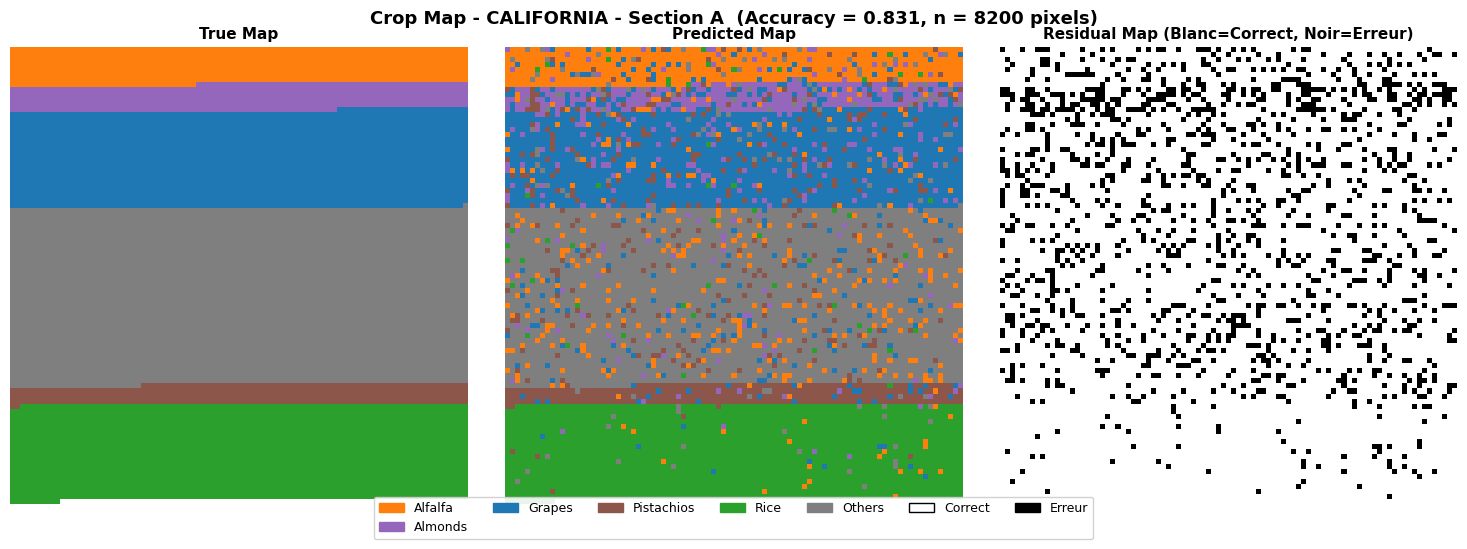

  Sauvegarde : data\processed\cropmap_AR_sectionA.png


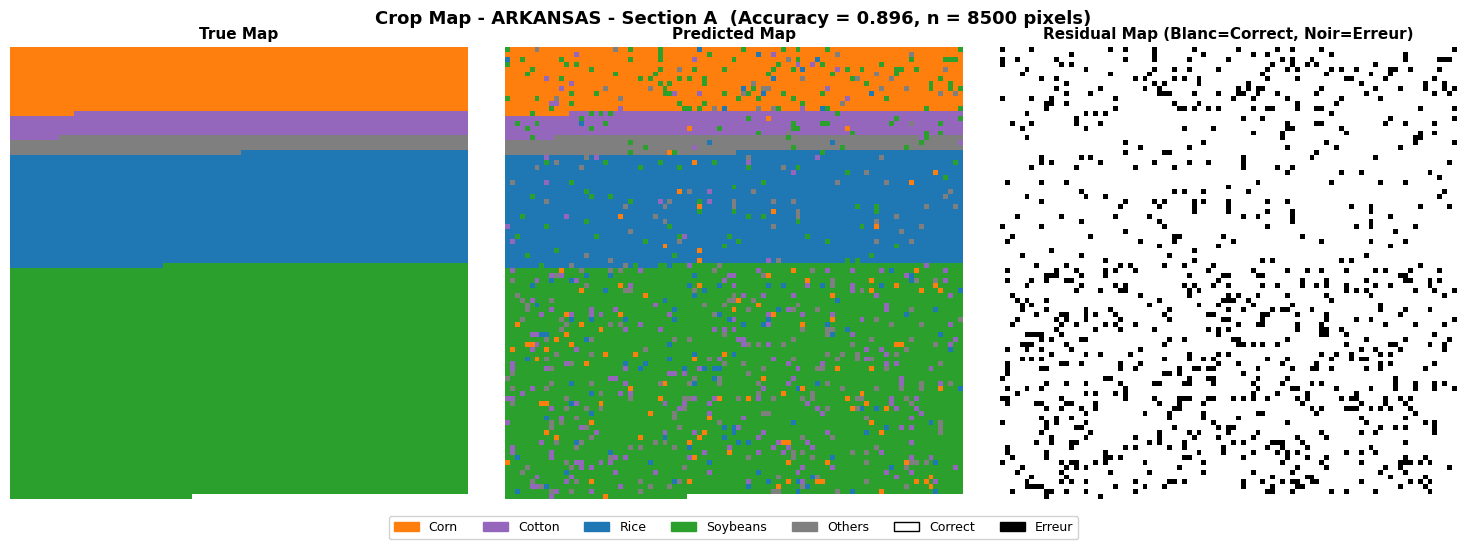

In [11]:
import matplotlib.patches as mpatches

# Couleurs CDL standard pour les cultures
CA_CROP_COLORS = {
    'Grapes':'#1f77b4', 'Rice':'#2ca02c', 'Alfalfa':'#ff7f0e',
    'Almonds':'#9467bd', 'Pistachios':'#8c564b', 'Others':'#7f7f7f',
}
AR_CROP_COLORS = {
    'Soybeans':'#2ca02c', 'Rice':'#1f77b4', 'Corn':'#ff7f0e',
    'Cotton':'#9467bd', 'Others':'#7f7f7f',
}


def _labels_to_rgb_grid(labels_enc, classes_list, color_map):
    """Convertit (N,) labels encodes en image RGB (h, w, 3) en grille carree."""
    n_pix = len(labels_enc)
    h = w = int(np.ceil(np.sqrt(n_pix)))
    img = np.ones((h * w, 3), dtype=np.float32)
    for i, enc in enumerate(labels_enc):
        cls = classes_list[enc]
        hex_c = color_map.get(cls, '#cccccc')
        r = int(hex_c[1:3], 16) / 255
        g = int(hex_c[3:5], 16) / 255
        b = int(hex_c[5:7], 16) / 255
        img[i] = [r, g, b]
    return img.reshape(h, w, 3)


def simulate_crop_map(y_true, y_pred, classes_list, color_map, label,
                       order=None, save_path=None):
    """Carte True/Predicted/Residual style Fig. 9-10 du paper.
       Pixels arranges en grille carree (pas de coords geo dans le CSV)."""
    n_pix = len(y_true)
    h = w = int(np.ceil(np.sqrt(n_pix)))

    img_true = _labels_to_rgb_grid(y_true, classes_list, color_map)
    img_pred = _labels_to_rgb_grid(y_pred, classes_list, color_map)

    residual = np.ones((h * w, 3), dtype=np.float32)
    for i in range(n_pix):
        if y_true[i] != y_pred[i]:
            residual[i] = [0, 0, 0]
    residual = residual.reshape(h, w, 3)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5.2))
    axes[0].imshow(img_true)
    axes[0].set_title('True Map', fontsize=11, fontweight='bold')
    axes[1].imshow(img_pred)
    axes[1].set_title('Predicted Map', fontsize=11, fontweight='bold')
    axes[2].imshow(residual)
    axes[2].set_title('Residual Map (Blanc=Correct, Noir=Erreur)',
                      fontsize=11, fontweight='bold')
    for ax in axes:
        ax.axis('off')

    if order is None:
        order = sorted(classes_list)
    patches = [mpatches.Patch(color=color_map.get(c, '#ccc'), label=c)
               for c in order if c in classes_list]
    patches += [
        mpatches.Patch(color='white', label='Correct', ec='black'),
        mpatches.Patch(color='black', label='Erreur'),
    ]
    fig.legend(handles=patches, loc='lower center', ncol=min(len(patches), 7),
               bbox_to_anchor=(0.5, -0.05), fontsize=9, framealpha=0.9)

    pct_correct = (y_true == y_pred).mean()
    plt.suptitle(f'Crop Map - {label}  (Accuracy = {pct_correct:.3f}, n = {n_pix} pixels)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'  Sauvegarde : {save_path}')
    plt.show()


print('Crop map helpers prets')


# Carte CALIFORNIA - Section A
simulate_crop_map(
    y_true=res_CA_p1['y_true'], y_pred=res_CA_p1['pred'],
    classes_list=list(data_CA_p1['le'].classes_),
    color_map=CA_CROP_COLORS, label='CALIFORNIA - Section A',
    order=['Alfalfa','Almonds','Grapes','Pistachios','Rice','Others'],
    save_path=PROCESSED_DIR / 'cropmap_CA_sectionA.png',
)

# Carte ARKANSAS - Section A
simulate_crop_map(
    y_true=res_AR_p1['y_true'], y_pred=res_AR_p1['pred'],
    classes_list=list(data_AR_p1['le'].classes_),
    color_map=AR_CROP_COLORS, label='ARKANSAS - Section A',
    order=['Corn','Cotton','Rice','Soybeans','Others'],
    save_path=PROCESSED_DIR / 'cropmap_AR_sectionA.png',
)


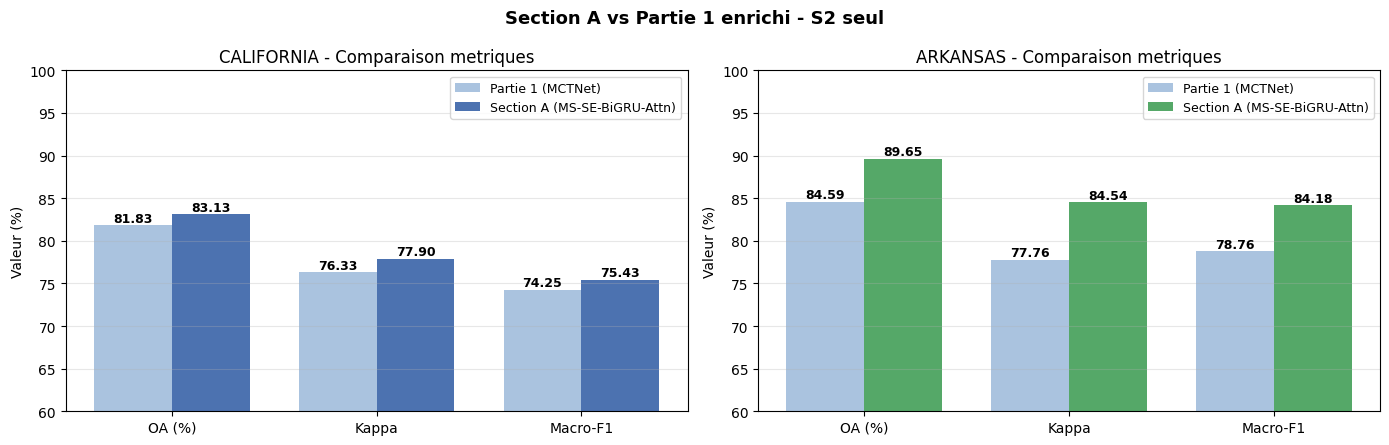

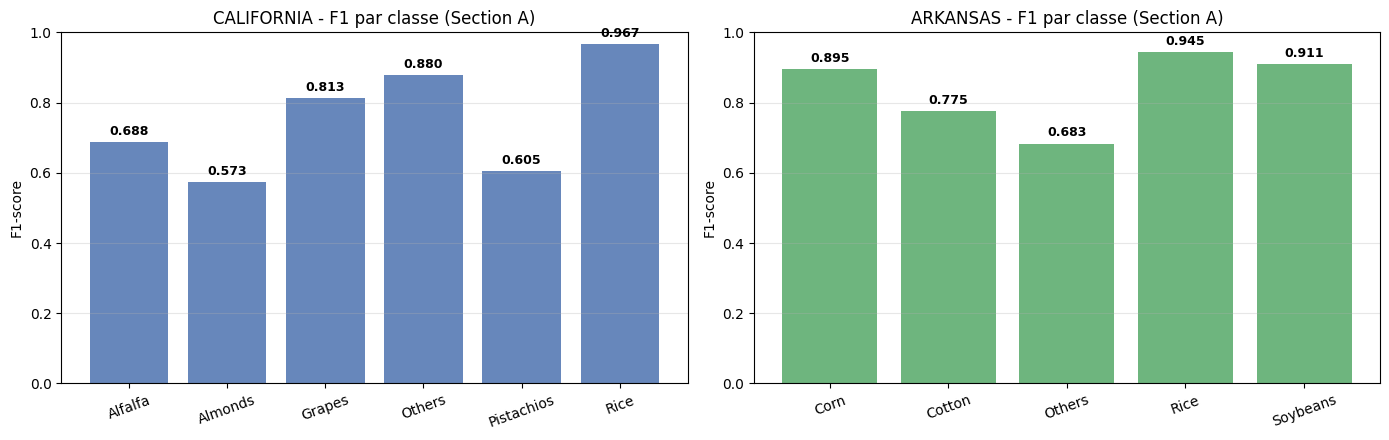

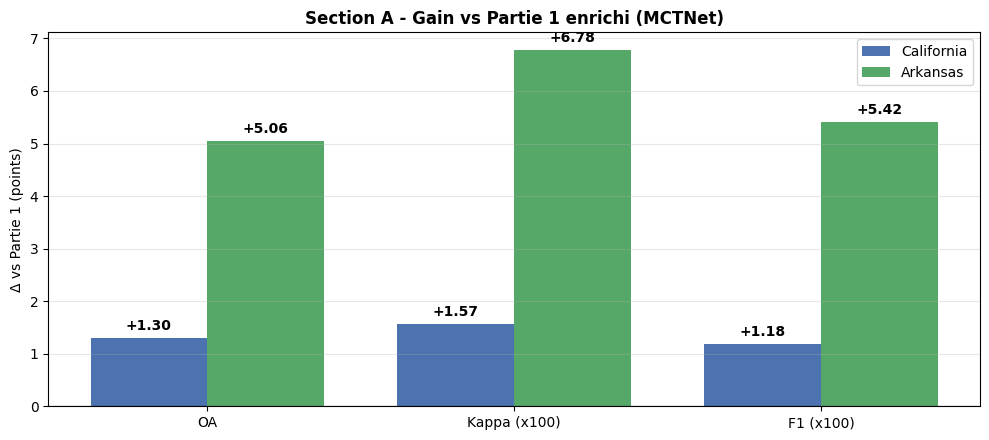


=== Tableau Section A vs Partie 1 enrichi ===
      Zone                       Modele    OA  Kappa     F1
CALIFORNIA            Partie 1 - MCTNet 81.83 0.7633 0.7425
CALIFORNIA Section A - MS-SE-BiGRU-Attn 83.13 0.7790 0.7543
  ARKANSAS            Partie 1 - MCTNet 84.59 0.7776 0.7876
  ARKANSAS Section A - MS-SE-BiGRU-Attn 89.65 0.8454 0.8418

✔ saved: data\processed/comparaison_sectionA_vs_partie1.csv


In [12]:
# === Valeurs hardcodees Partie 1 enrichi (MCTNet S2 only, split 240/60/reste)
P1_CA = {'OA': 81.83, 'Kappa': 0.7633, 'F1': 0.7425}
P1_AR = {'OA': 84.59, 'Kappa': 0.7776, 'F1': 0.7876}

NEW_CA = {'OA': res_CA_p1['OA'], 'Kappa': res_CA_p1['Kappa'], 'F1': res_CA_p1['F1']}
NEW_AR = {'OA': res_AR_p1['OA'], 'Kappa': res_AR_p1['Kappa'], 'F1': res_AR_p1['F1']}


# 1) Bar chart 3 metriques cote a cote
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
metrics = ['OA (%)', 'Kappa', 'Macro-F1']

for ax, (zone, p1, new, color) in zip(axes, [
    ('CALIFORNIA', P1_CA, NEW_CA, '#4C72B0'),
    ('ARKANSAS',   P1_AR, NEW_AR, '#55A868')
]):
    p1_vals  = [p1['OA'],  p1['Kappa']*100,  p1['F1']*100]
    new_vals = [new['OA'], new['Kappa']*100, new['F1']*100]
    x = np.arange(len(metrics)); w = 0.38
    b1 = ax.bar(x - w/2, p1_vals,  w, label='Partie 1 (MCTNet)',         color='#aac3df')
    b2 = ax.bar(x + w/2, new_vals, w, label='Section A (MS-SE-BiGRU-Attn)', color=color)
    ax.set_xticks(x); ax.set_xticklabels(metrics)
    ax.set_ylabel('Valeur (%)'); ax.set_title(f'{zone} - Comparaison metriques')
    ax.set_ylim([60, 100]); ax.grid(axis='y', alpha=0.3); ax.legend(fontsize=9)
    for b, v in list(zip(b1, p1_vals)) + list(zip(b2, new_vals)):
        ax.text(b.get_x() + b.get_width()/2, v + 0.4, f'{v:.2f}',
                ha='center', fontsize=9, fontweight='bold')
plt.suptitle('Section A vs Partie 1 enrichi - S2 seul', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


# 2) Per-class F1 comparison (necessite la confusion par classe)
def per_class_f1(y_true, y_pred, classes):
    f1s = []
    for cls_idx, cls_name in enumerate(classes):
        yt = (y_true == cls_idx).astype(int)
        yp = (y_pred == cls_idx).astype(int)
        f1s.append(f1_score(yt, yp, zero_division=0))
    return f1s

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, (zone, data, res, le, color) in zip(axes, [
    ('CALIFORNIA', data_CA_p1, res_CA_p1, data_CA_p1['le'], '#4C72B0'),
    ('ARKANSAS',   data_AR_p1, res_AR_p1, data_AR_p1['le'], '#55A868')
]):
    classes = list(le.classes_)
    f1_new = per_class_f1(res['y_true'], res['pred'], classes)
    x = np.arange(len(classes))
    bars = ax.bar(x, f1_new, color=color, alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(classes, rotation=20)
    ax.set_ylabel('F1-score'); ax.set_title(f'{zone} - F1 par classe (Section A)')
    ax.set_ylim([0, 1]); ax.grid(axis='y', alpha=0.3)
    for b, v in zip(bars, f1_new):
        ax.text(b.get_x() + b.get_width()/2, v + 0.02, f'{v:.3f}',
                ha='center', fontsize=9, fontweight='bold')
plt.tight_layout(); plt.show()


# 3) Delta OA / Kappa / F1 (gain absolu)
delta_CA = {
    'OA':    NEW_CA['OA'] - P1_CA['OA'],
    'Kappa': (NEW_CA['Kappa'] - P1_CA['Kappa']) * 100,
    'F1':    (NEW_CA['F1'] - P1_CA['F1']) * 100,
}
delta_AR = {
    'OA':    NEW_AR['OA'] - P1_AR['OA'],
    'Kappa': (NEW_AR['Kappa'] - P1_AR['Kappa']) * 100,
    'F1':    (NEW_AR['F1'] - P1_AR['F1']) * 100,
}

fig, ax = plt.subplots(figsize=(10, 4.5))
metrics_ = ['OA', 'Kappa (x100)', 'F1 (x100)']
ca_vals = [delta_CA['OA'], delta_CA['Kappa'], delta_CA['F1']]
ar_vals = [delta_AR['OA'], delta_AR['Kappa'], delta_AR['F1']]
x = np.arange(len(metrics_)); w = 0.38
b1 = ax.bar(x - w/2, ca_vals, w, label='California', color='#4C72B0')
b2 = ax.bar(x + w/2, ar_vals, w, label='Arkansas',   color='#55A868')
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(metrics_)
ax.set_ylabel('Δ vs Partie 1 (points)')
ax.set_title('Section A - Gain vs Partie 1 enrichi (MCTNet)', fontweight='bold')
ax.grid(axis='y', alpha=0.3); ax.legend()
for b, v in list(zip(b1, ca_vals)) + list(zip(b2, ar_vals)):
    off = 0.15 if v >= 0 else -0.5
    ax.text(b.get_x() + b.get_width()/2, v + off, f'{v:+.2f}',
            ha='center', fontsize=10, fontweight='bold')
plt.tight_layout(); plt.show()


# 4) Tableau recap clair
df_cmp = pd.DataFrame([
    {'Zone':'CALIFORNIA','Modele':'Partie 1 - MCTNet',          'OA':P1_CA['OA'],    'Kappa':P1_CA['Kappa'],    'F1':P1_CA['F1']},
    {'Zone':'CALIFORNIA','Modele':'Section A - MS-SE-BiGRU-Attn','OA':NEW_CA['OA'],   'Kappa':NEW_CA['Kappa'],   'F1':NEW_CA['F1']},
    {'Zone':'ARKANSAS',  'Modele':'Partie 1 - MCTNet',          'OA':P1_AR['OA'],    'Kappa':P1_AR['Kappa'],    'F1':P1_AR['F1']},
    {'Zone':'ARKANSAS',  'Modele':'Section A - MS-SE-BiGRU-Attn','OA':NEW_AR['OA'],   'Kappa':NEW_AR['Kappa'],   'F1':NEW_AR['F1']},
])
df_cmp['OA']    = df_cmp['OA'].round(2)
df_cmp['Kappa'] = df_cmp['Kappa'].round(4)
df_cmp['F1']    = df_cmp['F1'].round(4)
print('\n=== Tableau Section A vs Partie 1 enrichi ===')
print(df_cmp.to_string(index=False))
df_cmp.to_csv(PROCESSED_DIR / 'comparaison_sectionA_vs_partie1.csv', index=False)
print(f'\n✔ saved: {PROCESSED_DIR}/comparaison_sectionA_vs_partie1.csv')


---

# Section B - Ablation covariables avec MS-SE-BiGRU-Attn

## Objectif de la Section

Tester notre architecture **MS-SE-BiGRU-Attn** sur l'ablation study des **5 configurations** de Partie 2, en utilisant les **memes CSV** et les **memes splits** -> comparaison strictement equitable avec MCTNet+Cov.

5 configurations testees :
- `S2_only`    : 10 bandes Sentinel-2 seules (baseline)
- `S2_climate` : S2 + 3 cov climatiques (`temp_mean_c`, `precip_mm`, `dewpoint_c`)
- `S2_soil`    : S2 + 3 cov sol (`soil_ph`, `soil_oc`, `soil_texture`)
- `S2_topo`    : S2 + 2 cov topographiques (`elevation_m`, `landform_class`)
- `S2_all`     : S2 + 8 cov (toutes les precedentes combinees)

## 1. Source de donnees



## 2. Architecture : MS-SE-BiGRU-Attn dual-branch avec hybride per-zone

### Composants

| Bloc | Role |
|------|------|
| **MultiScaleConv1D** (kernels dilates 1/2/4) | Capture phenologie courte/moyenne/longue en parallele |
| **SEBlock1D** (channel attention) | Pondere adaptativement les bandes informatives |
| **BiGRU 2-layer** | Dependances temporelles bidirectionnelles |
| **MultiHeadAttention** (4 heads, masquee) | Repondering inter-dates respectant les slots manquants |
| **FFN + LayerNorm** | Capacite expressive supplementaire post-attention |
| **AttentionPool** | Aggregation temporelle ponderee (vs mean/max) |
| **MLP statique** (cov uniquement) | Branche dediee pour les covariables non-temporelles |
| **Fusion + Classifier** | Concat S2 + cov -> MLP -> num_classes |

### Dual-branch design

- **Branche S2 (temporelle)** : traite les 10 bandes Sentinel-2 sur 36 dates avec tout le pipeline (Conv + SE + BiGRU + MHSA + AttnPool)
- **Branche Cov (statique)** : MLP qui traite les covariables comme valeurs scalaires (extraites a t=0 car constantes dans le temps)
- **Fusion** : concat des deux representations avant le classifier final

### Mode hybride per-zone

Selon la zone, le comportement change :

| Zone | Mode | Effet |
|------|------|-------|
| **CALIFORNIA** | dual-branch pur (`use_hybrid=False`) | Branche S2 voit S2 pur (10 bandes). Cov traitee uniquement par MLP statique. Adapte aux **pereenes** (terroir statique discriminant : pH, elevation) |
| **ARKANSAS** | mode hybride (`use_hybrid=True`) | Pour small-cov (n_cov<=3), cov broadcast comme bandes additionnelles ET via MLP. Adapte aux **cultures annuelles** ou le climat module la signature spectrale temporelle (Rice avec precip elevees) |

`S2_all` (n_cov=8) reste en dual-branch pur dans les 2 zones car broadcast saturerait la branche S2.

## 3. Recette d'entrainement

### Optimiseur et scheduler
- **AdamW** (vs Adam de Partie 2) : meilleure regularisation L2 pour modeles transformer-like
- **Warmup 10 epochs + Cosine annealing** : convergence stable
- **Gradient clipping** max_norm=1.0 : evite divergence sur loss avec bruit

### Augmentations (sur train uniquement)
- **Bruit gaussien** sigma=0.02 sur slots presents (comme MCTNet Partie 1-2)
- **Time masking** : drop 3 slots aleatoires (~8% des dates)
- **MixUp** per-config :
  - alpha=0.30 pour `S2_only` (cov absente -> MixUp utile)
  - alpha=0.15-0.20 pour cov configs (mixage cov statiques cree des combinaisons douteuses)

### Regularisation
- **Class weights inverse frequence** : compensent le desequilibre (Soybeans 4677 vs Others 616 en AR)
- **Label smoothing** 0.10-0.15 selon config
- **Dropout** 0.25-0.30 sur 4 points (CNN, MHSA, FFN, FC final)
- **Weight decay** 1e-3 a 2e-3 selon config

### Early stopping
- Sur `val_loss` (plus stable que val_acc)
- Patience 50 epochs (laisse le temps de converger sur high-dim)

### Hyperparams per-config

| Config | Hidden | Dropout | LR | MixUp alpha | Patience |
|--------|--------|---------|-----|-------------|----------|
| `S2_only`    | 96  | 0.25 | 8e-4 | 0.30 | 50 |
| `S2_climate` | 96  | 0.25 | 7e-4 | 0.20 | 50 |
| `S2_soil`    | 96  | 0.28 | 6e-4 | 0.15 | 50 |
| `S2_topo`    | 96  | 0.25 | 7e-4 | 0.20 | 50 |
| `S2_all`     | 160 | 0.30 | 5e-4 | 0.20 | 50 |

## 4. Pipeline de la cellule

1. **Configuration** : hyperparams, paths, CONFIG_REGULARIZATION
2. **Loader** `build_enriched_datasets` : lit CSV, normalise, retourne 5 datasets
3. **Architecture** `MS_SE_BiGRU_Attn_Dual` : modele dual-branch
4. **Training** `train_config_B` : entrainement avec augs + class weights + cosine
5. **Run CA** : boucle sur 5 configs avec `use_hybrid=False`
6. **Run AR** : boucle sur 5 configs avec `use_hybrid=True`
7. **Visualisations** : courbes apprentissage + tableau ablation + matrices confusion + Grad-CAM
8. **Comparaison vs Partie 2** : graphes de gain (Delta OA / Kappa / F1)
9. **Sauvegarde** : modeles + CSV resultats

## Configuration Section B

In [13]:
# Hyperparametres Section B - Recovery v4 (AR friendly)
# - Mode hybride RE-ACTIVE pour n_cov<=3 (climate/soil/topo)
#   -> cov broadcast comme bandes ET via MLP statique
#   -> permet exploitation temporelle du climat (Rice depend des precip)
# - Hidden base = 96 (revenu de 128 trop gros)
# - S2_all : hidden_override=160 (garde)

N_BANDS      = 10
BATCH_SIZE_B = 32
LR_B         = 5e-4
EPOCHS_B     = 400
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

CONFIG_REGULARIZATION = {
    'S2_only'   : {'dropout': 0.25, 'wd': 1e-3, 'patience': 50, 'smooth': 0.10,
                   'lr': 8e-4, 'mixup_alpha': 0.3, 'hidden_override': None},
    'S2_climate': {'dropout': 0.25, 'wd': 1e-3, 'patience': 50, 'smooth': 0.10,
                   'lr': 7e-4, 'mixup_alpha': 0.2, 'hidden_override': None},
    'S2_soil'   : {'dropout': 0.28, 'wd': 1e-3, 'patience': 50, 'smooth': 0.12,
                   'lr': 6e-4, 'mixup_alpha': 0.15, 'hidden_override': None},
    'S2_topo'   : {'dropout': 0.25, 'wd': 1e-3, 'patience': 50, 'smooth': 0.10,
                   'lr': 7e-4, 'mixup_alpha': 0.2, 'hidden_override': None},
    'S2_all'    : {'dropout': 0.30, 'wd': 1e-3, 'patience': 50, 'smooth': 0.12,
                   'lr': 5e-4, 'mixup_alpha': 0.2, 'hidden_override': 160},
}

CSV_CA = PROCESSED_DIR / 'CALIFORNIA_FULL_split.csv'
CSV_AR = PROCESSED_DIR / 'ARKANSAS_FULL_split.csv'

CONFIGS = ['S2_only', 'S2_climate', 'S2_soil', 'S2_topo', 'S2_all']

print(f'CSV CA : {CSV_CA.exists()}')
print(f'CSV AR : {CSV_AR.exists()}')
print()
print(f'{"Config":<12} {"Bands":>5} {"Mode":<10} {"Hidden":>7} {"Dropout":>8} {"LR":>6} {"Mix":>5}')
print('-' * 65)
n_bands_map = {'S2_only': 10, 'S2_climate': 13, 'S2_soil': 13, 'S2_topo': 12, 'S2_all': 18}
for cfg in CONFIGS:
    r = CONFIG_REGULARIZATION[cfg]
    nb_ = n_bands_map[cfg]
    n_cov = nb_ - 10
    mode = 'hybride' if 0 < n_cov <= 3 else ('single' if n_cov == 0 else 'dual')
    h = r.get('hidden_override') or 96
    print(f'{cfg:<12} {nb_:>5} {mode:<10} {h:>7} {r["dropout"]:>8.2f} '
          f'{r["lr"]:>6.0e} {r["mixup_alpha"]:>5.2f}')


CSV CA : True
CSV AR : True

Config       Bands Mode        Hidden  Dropout     LR   Mix
-----------------------------------------------------------------
S2_only         10 single          96     0.25  8e-04  0.30
S2_climate      13 hybride         96     0.25  7e-04  0.20
S2_soil         13 hybride         96     0.28  6e-04  0.15
S2_topo         12 hybride         96     0.25  7e-04  0.20
S2_all          18 dual           160     0.30  5e-04  0.20


## Construction des 5 datasets enrichis

In [14]:
def build_enriched_datasets(csv_path, label, label_map=None):
    """Construit les 5 datasets pour l'ablation study (identique Partie 2).
       Lit covariables par pixel + split depuis colonne 'split' du CSV."""
    df = pd.read_csv(csv_path)

    # Harmonise label
    if 'label' in df.columns and 'crop_label' not in df.columns:
        df = df.rename(columns={'label': 'crop_label'})
    if label_map is not None:
        df['crop_label'] = df['crop_label'].map(label_map).fillna('Others')

    # Colonnes S2 et covariables
    COV_CLIMATE = ['temp_mean_c', 'precip_mm', 'dewpoint_c']
    COV_SOIL    = ['soil_ph', 'soil_oc', 'soil_texture']
    COV_TOPO    = ['elevation_m', 'landform_class']
    COV_ALL     = COV_CLIMATE + COV_SOIL + COV_TOPO
    META        = ['crop_label', 'split'] + COV_ALL

    s2_cols = [c for c in df.columns if c not in META]
    assert len(s2_cols) == N_BANDS * N_DATES, \
        f'[{label}] Attendu {N_BANDS*N_DATES} S2, got {len(s2_cols)}'

    # Split depuis CSV
    assert 'split' in df.columns, "Colonne split manquante dans le CSV !"
    vc = df['split'].value_counts()
    print(f'  [{label}] Split CSV : train={vc.get("train",0)} val={vc.get("val",0)} test={vc.get("test",0)}')

    tr = df['split'].values == 'train'
    va = df['split'].values == 'val'
    te = df['split'].values == 'test'

    # Interpolation zeros (nuages)
    X_s2_raw = df[s2_cols].copy().replace(0, np.nan)
    X_s2_raw = X_s2_raw.interpolate(axis=1, limit_direction='both').fillna(0)
    df[s2_cols] = X_s2_raw

    # Encodage labels
    le = LabelEncoder()
    y  = le.fit_transform(df['crop_label']).astype('int64')

    # Normalisation S2 (fit train)
    X_s2 = df[s2_cols].values.astype('float32')
    sc   = StandardScaler()
    X_s2[tr]  = sc.fit_transform(X_s2[tr])
    X_s2[~tr] = sc.transform(X_s2[~tr])
    X_s2_3d   = X_s2.reshape(len(df), N_DATES, N_BANDS)

    # Covariables normalisees
    def norm_cov(cols):
        if not all(c in df.columns for c in cols):
            return None
        arr = df[cols].values.astype('float32')
        sc2 = StandardScaler()
        arr_out = arr.copy()
        arr_out[tr]  = sc2.fit_transform(arr[tr])
        arr_out[~tr] = sc2.transform(arr[~tr])
        return arr_out

    clim = norm_cov(COV_CLIMATE)
    soil = norm_cov(COV_SOIL)
    topo = norm_cov(COV_TOPO)
    all_ = np.concatenate([x for x in [clim, soil, topo] if x is not None], axis=1)

    def add_cov(X_3d, cov_2d):
        N_, T, B = X_3d.shape
        cov_3d = np.tile(cov_2d[:, np.newaxis, :], (1, T, 1))
        return np.concatenate([X_3d, cov_3d], axis=2).reshape(N_, T*(B+cov_2d.shape[1]))

    configs_cov = {
        'S2_only'   : None,
        'S2_climate': clim,
        'S2_soil'   : soil,
        'S2_topo'   : topo,
        'S2_all'    : all_,
    }

    datasets = {}
    for name, cov_px in configs_cov.items():
        if cov_px is None:
            X_aug   = X_s2_3d.reshape(len(df), N_DATES * N_BANDS)
            n_extra = 0
        else:
            X_aug   = add_cov(X_s2_3d, cov_px)
            n_extra = cov_px.shape[1]

        datasets[name] = {
            'X_train': X_aug[tr], 'y_train': y[tr],
            'X_val'  : X_aug[va], 'y_val'  : y[va],
            'X_test' : X_aug[te], 'y_test' : y[te],
            'n_features'   : X_aug.shape[1],
            'n_bands_total': N_BANDS + n_extra,
            'n_extra'      : n_extra,
        }
        print(f'  [{label}] {name:<15} -> {X_aug.shape[1]:5d} feat  '
              f'({N_BANDS}+{n_extra} bandes x {N_DATES} dates)')

    return datasets, le


print('=== Construction datasets CALIFORNIA ===')
datasets_CA, le_CA = build_enriched_datasets(CSV_CA, 'CA', label_map=LABEL_MAP_CA)
print()
print('=== Construction datasets ARKANSAS ===')
datasets_AR, le_AR = build_enriched_datasets(CSV_AR, 'AR', label_map=LABEL_MAP_AR)


=== Construction datasets CALIFORNIA ===
  [CA] Split CSV : train=1440 val=360 test=8200
  [CA] S2_only         ->   360 feat  (10+0 bandes x 36 dates)
  [CA] S2_climate      ->   468 feat  (10+3 bandes x 36 dates)
  [CA] S2_soil         ->   468 feat  (10+3 bandes x 36 dates)
  [CA] S2_topo         ->   432 feat  (10+2 bandes x 36 dates)
  [CA] S2_all          ->   648 feat  (10+8 bandes x 36 dates)

=== Construction datasets ARKANSAS ===
  [AR] Split CSV : train=1200 val=300 test=8500
  [AR] S2_only         ->   360 feat  (10+0 bandes x 36 dates)
  [AR] S2_climate      ->   468 feat  (10+3 bandes x 36 dates)
  [AR] S2_soil         ->   468 feat  (10+3 bandes x 36 dates)
  [AR] S2_topo         ->   432 feat  (10+2 bandes x 36 dates)
  [AR] S2_all          ->   648 feat  (10+8 bandes x 36 dates)


## Architecture MS-SE-BiGRU-Attn (adaptee pour input flatten)

In [ ]:

class MS_SE_BiGRU_Attn_Dual(nn.Module):
    """Architecture dual-branch S2 temporel + cov statique."""
    def __init__(self, n_bands_total, num_classes, hidden=96, hidden_cov=32,
                 nhead=4, n_dates=36, dropout=0.25, n_s2_bands=10,
                 use_hybrid=None):
        super().__init__()
        hidden = ((hidden + nhead - 1) // nhead) * nhead
        self.n_bands_total = n_bands_total
        self.n_s2_bands    = n_s2_bands
        self.n_cov         = n_bands_total - n_s2_bands   # 0, 2, 3, ou 8
        self.n_dates       = n_dates
        self.hidden        = hidden

        # Mode hybride : pour small-cov (n_cov<=3), traiter cov comme bandes ET via MLP
        # Pour S2_all (n_cov>3), uniquement MLP (sinon trop de bandes pour S2 branch)
        if use_hybrid is None:
            self.use_cov_as_bands = (0 < self.n_cov <= 3)
        else:
            self.use_cov_as_bands = bool(use_hybrid) and (self.n_cov > 0)
        n_input_bands = n_s2_bands + (self.n_cov if self.use_cov_as_bands else 0)

        # === Branche 1 : S2 temporel (+ cov broadcast si small-cov) ===
        self.ms_conv  = MultiScaleConv1D(n_input_bands, hidden, kernel=3)
        self.se       = SEBlock1D(hidden, reduction=4)
        self.drop_cnn = nn.Dropout(dropout)

        self.gru = nn.GRU(
            input_size=hidden,
            hidden_size=hidden // 2,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=dropout,
        )

        self.attn = nn.MultiheadAttention(
            embed_dim=hidden, num_heads=nhead,
            dropout=dropout, batch_first=True,
        )
        self.norm1 = nn.LayerNorm(hidden)
        self.ffn = nn.Sequential(
            nn.Linear(hidden, hidden * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden * 2, hidden),
        )
        self.norm2 = nn.LayerNorm(hidden)
        self.pool = AttentionPool(hidden)

        # === Branche 2 : Covariables statiques (MLP) ===
        if self.n_cov > 0:
            self.cov_mlp = nn.Sequential(
                nn.Linear(self.n_cov, hidden_cov),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_cov, hidden_cov),
                nn.GELU(),
                nn.Dropout(dropout),
            )
            fusion_dim = hidden + hidden_cov
        else:
            self.cov_mlp = None
            fusion_dim = hidden

        # === Tete de classification ===
        self.dropout_fc = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(fusion_dim, fusion_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_dim // 2, num_classes),
        )

    def forward(self, x):
        B = x.size(0)
        x_3d = x.reshape(B, self.n_dates, self.n_bands_total)
        # Mask sur S2 uniquement
        s2 = x_3d[:, :, :self.n_s2_bands]                   # (B, T, 10)
        mask = (s2.abs().sum(dim=-1) > 0).float()

        # Branche 1 : S2 temporel (+ cov broadcast si small-cov)
        if self.use_cov_as_bands:
            x_branch1 = x_3d                                 # garde tout (B, T, 10+n_cov)
        else:
            x_branch1 = s2                                   # S2 seul
        h = x_branch1.transpose(1, 2)                       # (B, C, T)
        h = self.ms_conv(h)
        h = self.se(h)
        h = self.drop_cnn(h)
        h = h.transpose(1, 2)                               # (B, T, hidden)
        h, _ = self.gru(h)
        pad_mask = (mask == 0)
        a, _ = self.attn(h, h, h, key_padding_mask=pad_mask, need_weights=False)
        h = self.norm1(h + a)
        h = self.norm2(h + self.ffn(h))
        z_s2 = self.pool(h, mask=mask)                      # (B, hidden)

        # Branche 2 : Covariables statiques (si presentes)
        if self.cov_mlp is not None:
            cov = x_3d[:, 0, self.n_s2_bands:]              # (B, n_cov), valeur a t=0 (constant)
            z_cov = self.cov_mlp(cov)                       # (B, hidden_cov)
            z = torch.cat([z_s2, z_cov], dim=-1)            # (B, hidden + hidden_cov)
        else:
            z = z_s2

        return self.fc(self.dropout_fc(z))


def build_model_B(n_bands_total, num_classes, device, dropout=0.25, hidden_override=None, use_hybrid=None):
    h = hidden_override if hidden_override is not None else 96   # hidden base = 96
    h = ((h + 3) // 4) * 4   # multiple de 4 pour nhead
    # hidden_cov proportionnel a n_cov (anti-overfit MLP cov)
    # 3 cov -> 24 hidden, 2 cov -> 16, 8 cov -> 48
    n_cov = n_bands_total - 10
    if n_cov == 0:
        h_cov = 0
    elif n_cov <= 2:
        h_cov = 16
    elif n_cov <= 3:
        h_cov = 24
    else:
        h_cov = 48
    model = MS_SE_BiGRU_Attn_Dual(
        n_bands_total=n_bands_total, num_classes=num_classes,
        hidden=h, hidden_cov=h_cov,
        dropout=dropout, n_dates=N_DATES,
        use_hybrid=use_hybrid,
    ).to(device)
    total = sum(p.numel() for p in model.parameters())
    n_cov = n_bands_total - 10
    print(f'  MS-SE-BiGRU-Attn Dual | S2={10}({h})  Cov={n_cov}({h_cov})  '
          f'classes={num_classes}  params={total:,}  dropout={dropout}')
    return model


print('=== Test architecture Dual-branch ===')
for nb_ in [10, 12, 13, 18]:
    build_model_B(nb_, 6, DEVICE, dropout=0.25)
print('Architecture Dual-branch chargee')


=== Test architecture Dual-branch ===
  MS-SE-BiGRU-Attn Dual | S2=10(96)  Cov=0(0)  classes=6  params=171,727  dropout=0.25
  MS-SE-BiGRU-Attn Dual | S2=10(96)  Cov=2(16)  classes=6  params=174,343  dropout=0.25
  MS-SE-BiGRU-Attn Dual | S2=10(96)  Cov=3(24)  classes=6  params=175,963  dropout=0.25
  MS-SE-BiGRU-Attn Dual | S2=10(96)  Cov=8(48)  classes=6  params=180,439  dropout=0.25
Architecture Dual-branch chargee


## Entrainement (Ablation Study)

In [ ]:
def _mixup_batch_B(X, y, alpha):
    if alpha <= 0:
        return X, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    lam = max(lam, 1 - lam)
    idx = torch.randperm(X.size(0), device=X.device)
    X_mix = lam * X + (1 - lam) * X[idx]
    return X_mix, y, y[idx], lam


def _warmup_cosine_B(optimizer, total_epochs, warmup=10, eta_min_ratio=0.01):
    def f(ep):
        if ep < warmup:
            return (ep + 1) / warmup
        t = (ep - warmup) / max(total_epochs - warmup, 1)
        return eta_min_ratio + 0.5 * (1 - eta_min_ratio) * (1 + math.cos(math.pi * t))
    return optim.lr_scheduler.LambdaLR(optimizer, f)


def _eval_clean_B(model, loader, device):
    """Eval propre : mode eval, pas d'aug, pas de smoothing, pas de mixup."""
    model.eval()
    crit = nn.CrossEntropyLoss()   
    tl = 0.
    all_pred, all_true = [], []
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            out = model(X)
            tl += crit(out, y).item()
            all_pred.extend(out.argmax(1).cpu().numpy())
            all_true.extend(y.cpu().numpy())
    acc = 100 * np.mean(np.array(all_pred) == np.array(all_true))
    loss = tl / max(len(loader), 1)
    f1 = f1_score(all_true, all_pred, average='macro', zero_division=0)
    return loss, acc, f1


def train_config_B(datasets, config_name, num_classes, device, label, epochs=None, use_hybrid=None):
    """Entrainement optimise pour MS-SE-BiGRU-Attn + clean eval pass.
       hist enrichi avec clean_loss, clean_acc, clean_f1 -> courbes propres."""
    if epochs is None:
        epochs = EPOCHS_B
    reg = CONFIG_REGULARIZATION[config_name]
    dropout      = reg['dropout']
    weight_decay = reg['wd']
    patience     = reg['patience']
    smooth       = reg['smooth']
    lr           = reg['lr']
    mixup_alpha  = reg['mixup_alpha']
    hidden_override = reg.get('hidden_override')

    d             = datasets[config_name]
    n_bands_total = d['n_bands_total']

    def add_noise(X, sigma=0.02):
        nonzero = (X.abs().sum(dim=-1, keepdim=True) > 0).float()
        return X + torch.randn_like(X) * sigma * nonzero

    def add_time_mask(X, n_mask=3):
        
        N_, feat = X.shape
        n_bands_ = feat // N_DATES
        X_3d = X.reshape(N_, N_DATES, n_bands_).clone()
        # Genere des indices aleatoires uniformes (batch sample)
        idx = torch.randint(0, N_DATES, (N_, n_mask), device=X.device)
        # Set to 0 these slots
        batch_idx = torch.arange(N_, device=X.device).unsqueeze(1).expand(-1, n_mask)
        X_3d[batch_idx, idx, :] = 0.0
        return X_3d.reshape(N_, feat)

    def make_loader(X, y, shuffle=False):
        ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
        return DataLoader(ds, batch_size=BATCH_SIZE_B, shuffle=shuffle,
                          num_workers=0, pin_memory=(device.type == 'cuda'))

    tr_loader = make_loader(d['X_train'], d['y_train'], shuffle=True)
    va_loader = make_loader(d['X_val'],   d['y_val'])

    model = build_model_B(n_bands_total, num_classes, device,
                          dropout=dropout, hidden_override=hidden_override,
                          use_hybrid=use_hybrid)

    y_train = d['y_train']
    counts  = np.bincount(y_train, minlength=num_classes).astype(np.float32)
    weights = counts.sum() / (num_classes * counts + 1e-8)
    weights = torch.tensor(weights, dtype=torch.float32).to(device)

    crit = nn.CrossEntropyLoss(weight=weights, label_smoothing=smooth)
    opt  = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = _warmup_cosine_B(opt, epochs, warmup=10)

    best_vl    = float('inf')
    best_state = None
    best_epoch = 0
    wait       = 0
    hist = {
        'loss': [], 'acc': [], 'train_f1': [],
        'val_loss': [], 'val_acc': [], 'val_f1': [],
        'clean_loss': [], 'clean_acc': [], 'clean_f1': [],   
        'config': config_name, 'label': label,
    }

    print(f'\n  [{label}] {config_name}  ({n_bands_total}x{N_DATES} feat)  '
          f'dropout={dropout} lr={lr:.0e} wd={weight_decay:.0e} mixup={mixup_alpha} patience={patience}')

    for ep in range(epochs):
        # Train
        model.train()
        tl = 0.
        all_tr_pred, all_tr_true = [], []
        for X, y in tr_loader:
            X, y = X.to(device), y.to(device)
            X_aug = X.reshape(X.size(0), N_DATES, -1)
            X_aug = add_noise(X_aug)
            X_aug = X_aug.reshape(X.size(0), -1)
            X_aug = add_time_mask(X_aug)

            X_in, y_a, y_b, lam = _mixup_batch_B(X_aug, y, mixup_alpha)

            opt.zero_grad()
            out = model(X_in)
            if mixup_alpha > 0:
                loss = lam * crit(out, y_a) + (1 - lam) * crit(out, y_b)
            else:
                loss = crit(out, y_a)

            if torch.isnan(loss):
                continue
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tl += loss.item()
            all_tr_pred.extend(out.argmax(1).cpu().numpy())
            all_tr_true.extend(y_a.cpu().numpy())
        sched.step()

        ta  = 100 * np.mean(np.array(all_tr_pred) == np.array(all_tr_true))
        tl_ = tl / max(len(tr_loader), 1)
        tf1 = f1_score(all_tr_true, all_tr_pred, average='macro', zero_division=0)

        # Validation
        model.eval()
        vl = 0.
        all_va_pred, all_va_true = [], []
        with torch.no_grad():
            for X, y in va_loader:
                X, y = X.to(device), y.to(device)
                out = model(X)
                vl  += crit(out, y).item()
                all_va_pred.extend(out.argmax(1).cpu().numpy())
                all_va_true.extend(y.cpu().numpy())
        va  = 100 * np.mean(np.array(all_va_pred) == np.array(all_va_true))
        vl_ = vl / max(len(va_loader), 1)
        vf1 = f1_score(all_va_true, all_va_pred, average='macro', zero_division=0)

       
        if ep == 0 or (ep + 1) % 5 == 0 or wait >= patience - 1:
            cl_loss, cl_acc, cl_f1 = _eval_clean_B(model, tr_loader, device)

        hist['loss'].append(tl_);     hist['acc'].append(ta);     hist['train_f1'].append(tf1)
        hist['val_loss'].append(vl_); hist['val_acc'].append(va); hist['val_f1'].append(vf1)
        hist['clean_loss'].append(cl_loss); hist['clean_acc'].append(cl_acc); hist['clean_f1'].append(cl_f1)

        if vl_ < best_vl:
            best_vl    = vl_
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            best_epoch = ep + 1
            wait       = 0
        else:
            wait += 1
            if wait >= patience:
                print(f'  Early stop ep={ep+1}  best ep={best_epoch}  val_loss={best_vl:.4f}')
                break

        if (ep + 1) % 25 == 0 or ep == 0:
            print(f'  [{ep+1:>3d}/{epochs}]  '
                  f'CleanTr l={cl_loss:.3f} a={cl_acc:.1f}% F1={cl_f1:.3f}  |  '
                  f'Va l={vl_:.3f} a={va:.1f}% F1={vf1:.3f}  wait={wait}/{patience}')

    if best_state:
        model.load_state_dict(best_state)
    hist['best_epoch'] = best_epoch
    print(f'  OK Best ep={best_epoch}  val_loss={best_vl:.4f}  val_F1={hist["val_f1"][best_epoch-1]:.4f}')
    return model, hist


def evaluate_config_B(model, datasets, config_name, device):
    d = datasets[config_name]
    model.eval()
    with torch.no_grad():
        pred = model(
            torch.from_numpy(d['X_test']).to(device)
        ).argmax(1).cpu().numpy()
    y = d['y_test']
    return {
        'OA'    : 100 * (pred == y).mean(),
        'Kappa' : cohen_kappa_score(y, pred),
        'F1'    : f1_score(y, pred, average='macro'),
        'pred'  : pred,
        'y_true': y,
    }


print('train_config_B + eval_clean_B - tracking clean acc/loss/F1 separe')


train_config_B + eval_clean_B - tracking clean acc/loss/F1 separe


In [17]:
# CALIFORNIA - Ablation 5 configs
results_CA = {}
models_CA  = {}
hists_CA   = {}

print('=' * 55)
print('  ABLATION STUDY - CALIFORNIA (MS-SE-BiGRU-Attn)')
print('=' * 55)

for cfg in CONFIGS:
    model, hist = train_config_B(datasets_CA, cfg, len(le_CA.classes_), DEVICE, 'CA', use_hybrid=False)
    metrics     = evaluate_config_B(model, datasets_CA, cfg, DEVICE)
    results_CA[cfg] = metrics
    models_CA[cfg]  = model
    hists_CA[cfg]   = hist
    print(f'  {cfg:<15} OA={metrics["OA"]:.2f}%  '
          f'Kappa={metrics["Kappa"]:.3f}  F1={metrics["F1"]:.3f}')

print('\nCalifornia termine')


  ABLATION STUDY - CALIFORNIA (MS-SE-BiGRU-Attn)
  MS-SE-BiGRU-Attn Dual | S2=10(96)  Cov=0(0)  classes=6  params=171,727  dropout=0.25

  [CA] S2_only  (10x36 feat)  dropout=0.25 lr=8e-04 wd=1e-03 mixup=0.3 patience=50


  [  1/400]  CleanTr l=1.689 a=39.9% F1=0.322  |  Va l=1.707 a=39.2% F1=0.317  wait=0/50
  [ 25/400]  CleanTr l=0.685 a=79.7% F1=0.796  |  Va l=0.942 a=74.4% F1=0.739  wait=1/50
  [ 50/400]  CleanTr l=0.503 a=86.5% F1=0.860  |  Va l=0.887 a=76.7% F1=0.762  wait=3/50
  [ 75/400]  CleanTr l=0.317 a=94.4% F1=0.944  |  Va l=0.882 a=79.4% F1=0.791  wait=5/50
  [100/400]  CleanTr l=0.239 a=97.8% F1=0.978  |  Va l=0.869 a=78.9% F1=0.788  wait=30/50
  Early stop ep=120  best ep=70  val_loss=0.8174
  OK Best ep=70  val_loss=0.8174  val_F1=0.8003
  S2_only         OA=81.94%  Kappa=0.762  F1=0.744
  MS-SE-BiGRU-Attn Dual | S2=10(96)  Cov=3(24)  classes=6  params=175,099  dropout=0.25

  [CA] S2_climate  (13x36 feat)  dropout=0.25 lr=7e-04 wd=1e-03 mixup=0.2 patience=50
  [  1/400]  CleanTr l=1.692 a=30.8% F1=0.216  |  Va l=1.705 a=31.1% F1=0.231  wait=0/50
  [ 25/400]  CleanTr l=0.612 a=81.0% F1=0.808  |  Va l=0.926 a=77.8% F1=0.774  wait=2/50
  [ 50/400]  CleanTr l=0.398 a=90.9% F1=0.909  |  Va 

In [18]:
# ARKANSAS - Ablation 5 configs
results_AR = {}
models_AR  = {}
hists_AR   = {}

print('=' * 55)
print('  ABLATION STUDY - ARKANSAS (MS-SE-BiGRU-Attn)')
print('=' * 55)

for cfg in CONFIGS:
    model, hist = train_config_B(datasets_AR, cfg, len(le_AR.classes_), DEVICE, 'AR', use_hybrid=True)
    metrics     = evaluate_config_B(model, datasets_AR, cfg, DEVICE)
    results_AR[cfg] = metrics
    models_AR[cfg]  = model
    hists_AR[cfg]   = hist
    print(f'  {cfg:<15} OA={metrics["OA"]:.2f}%  '
          f'Kappa={metrics["Kappa"]:.3f}  F1={metrics["F1"]:.3f}')

print('\nArkansas termine')


  ABLATION STUDY - ARKANSAS (MS-SE-BiGRU-Attn)
  MS-SE-BiGRU-Attn Dual | S2=10(96)  Cov=0(0)  classes=5  params=171,678  dropout=0.25

  [AR] S2_only  (10x36 feat)  dropout=0.25 lr=8e-04 wd=1e-03 mixup=0.3 patience=50
  [  1/400]  CleanTr l=1.533 a=38.8% F1=0.306  |  Va l=1.554 a=39.0% F1=0.325  wait=0/50
  [ 25/400]  CleanTr l=0.400 a=90.8% F1=0.907  |  Va l=0.744 a=83.7% F1=0.836  wait=0/50
  [ 50/400]  CleanTr l=0.196 a=96.8% F1=0.968  |  Va l=0.715 a=84.3% F1=0.844  wait=7/50
  [ 75/400]  CleanTr l=0.157 a=98.8% F1=0.988  |  Va l=0.706 a=84.7% F1=0.846  wait=32/50
  Early stop ep=93  best ep=43  val_loss=0.6911
  OK Best ep=43  val_loss=0.6911  val_F1=0.8538
  S2_only         OA=77.21%  Kappa=0.681  F1=0.714
  MS-SE-BiGRU-Attn Dual | S2=10(96)  Cov=3(24)  classes=5  params=175,902  dropout=0.25

  [AR] S2_climate  (13x36 feat)  dropout=0.25 lr=7e-04 wd=1e-03 mixup=0.2 patience=50
  [  1/400]  CleanTr l=1.545 a=39.0% F1=0.344  |  Va l=1.562 a=35.3% F1=0.311  wait=0/50
  [ 25/400]  C

## Courbes d'apprentissage (Overfitting / Underfitting)

=== Courbes - CALIFORNIA ===


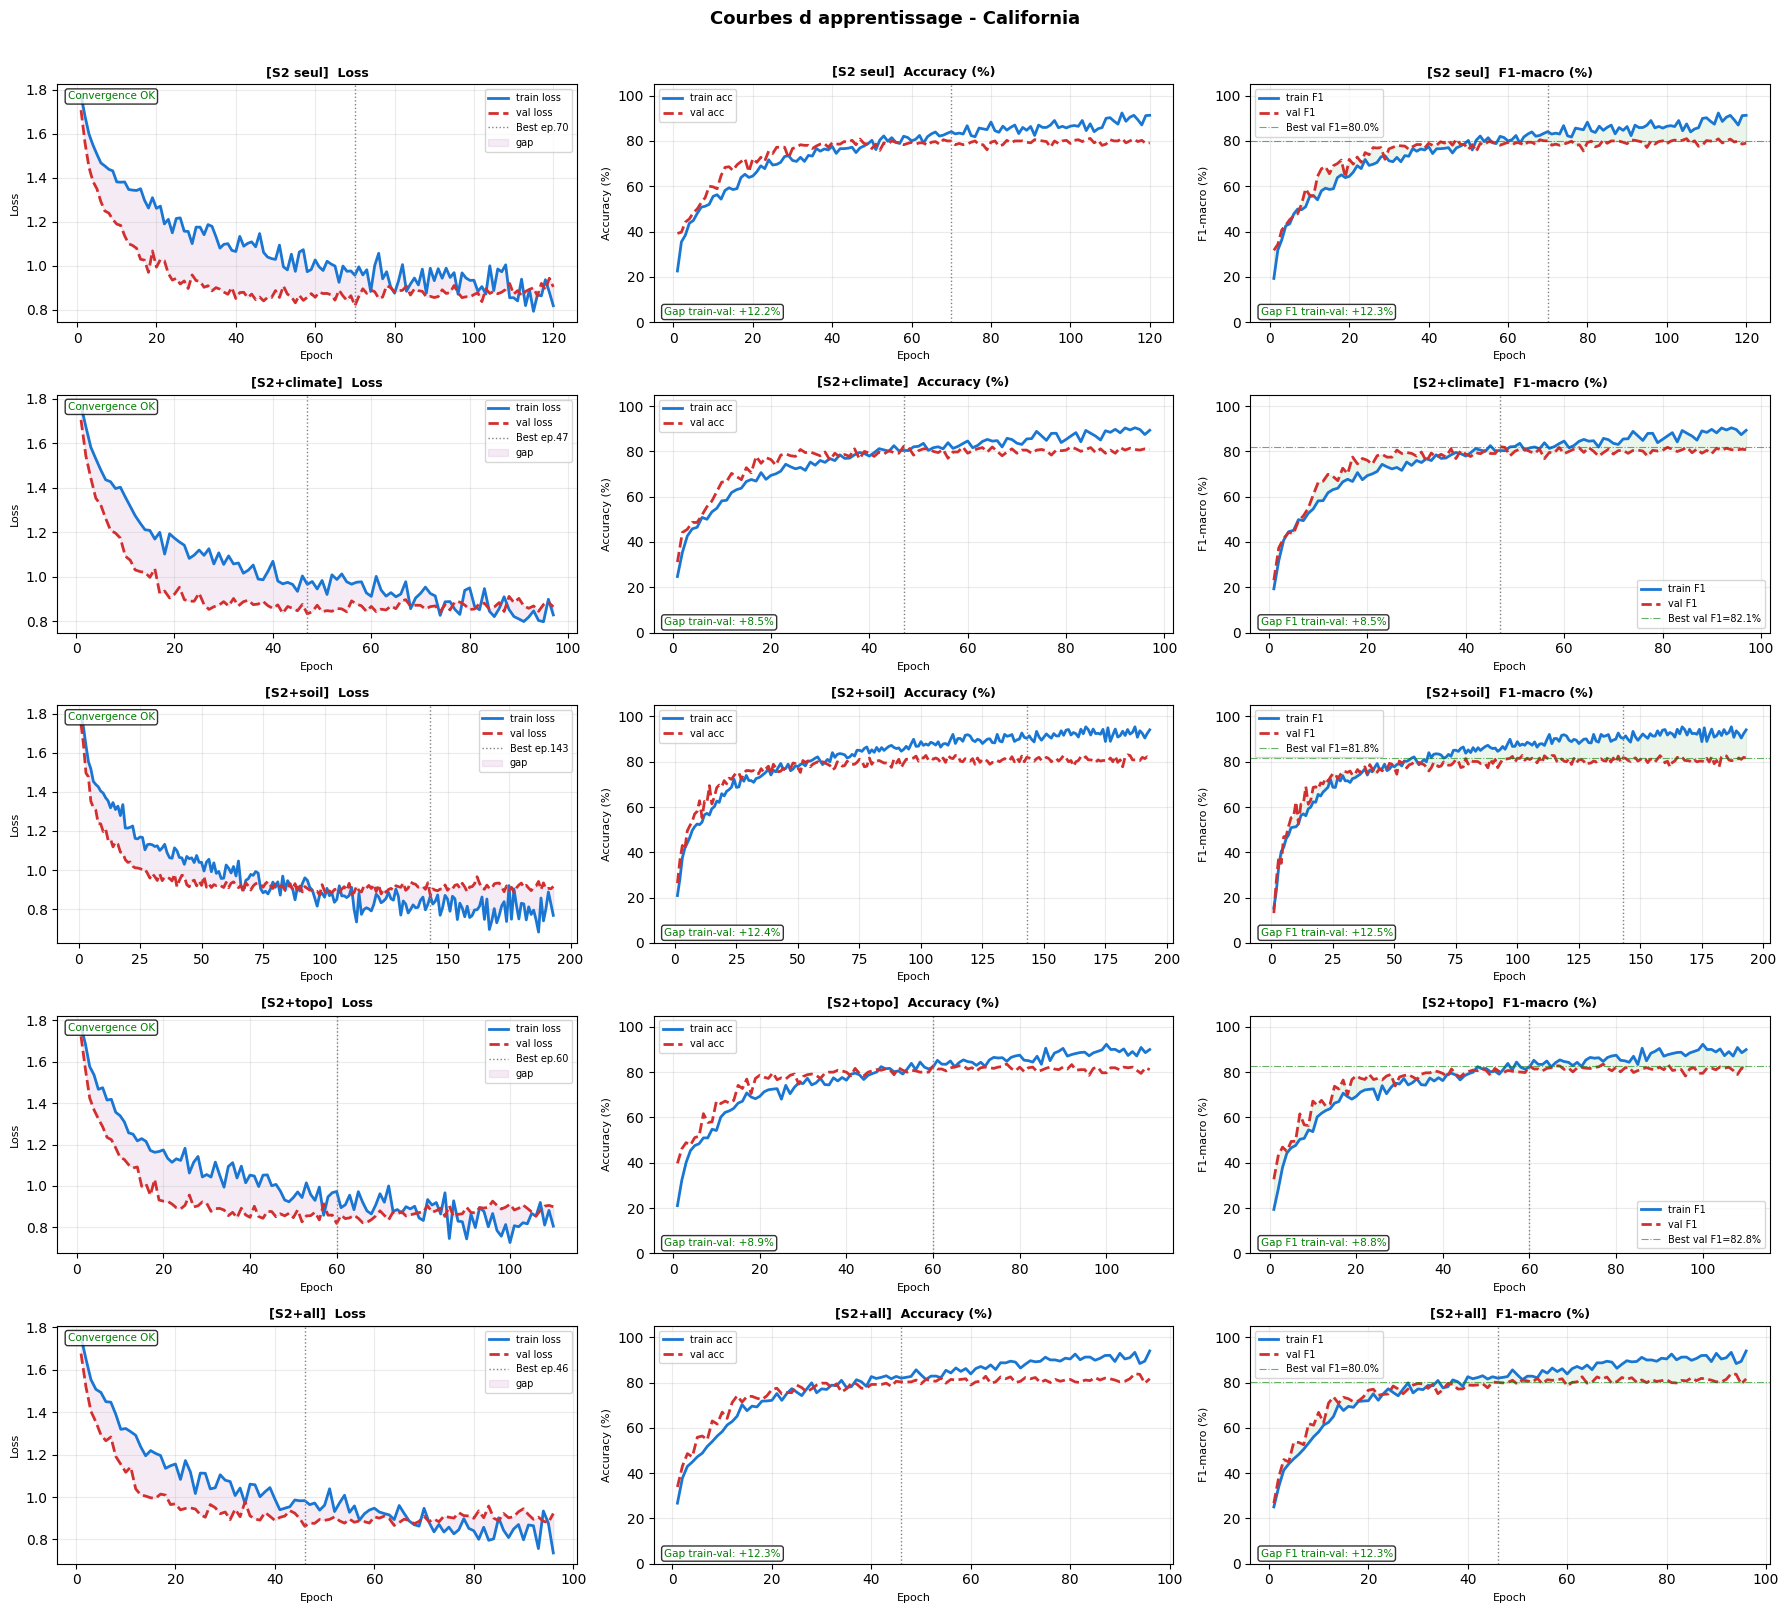


=== Courbes - ARKANSAS ===


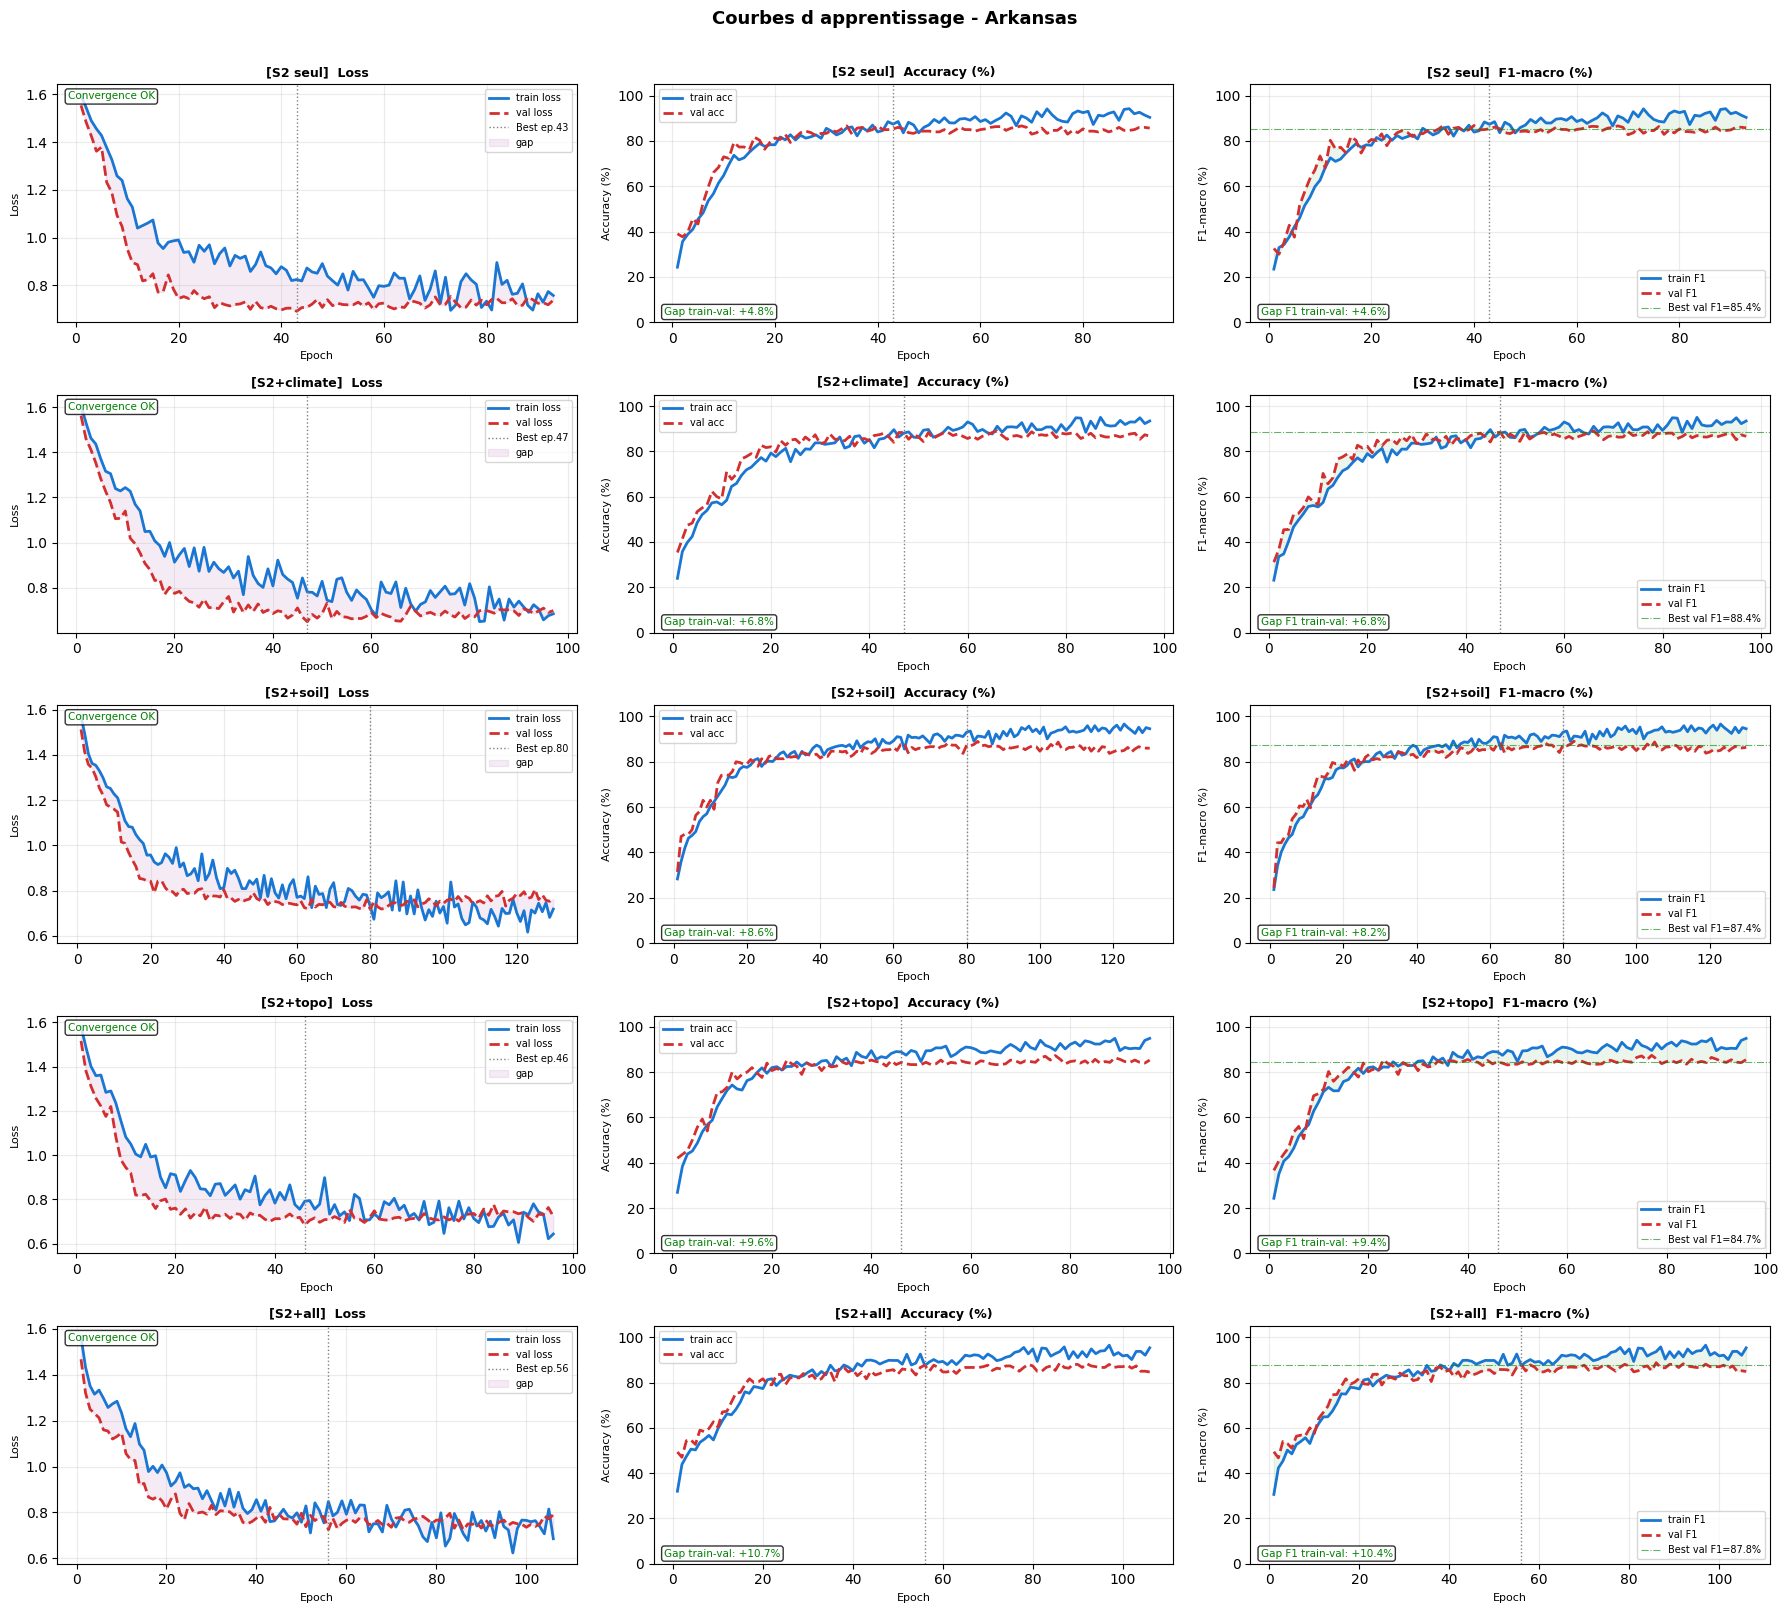


=== Synthese Overfitting ===


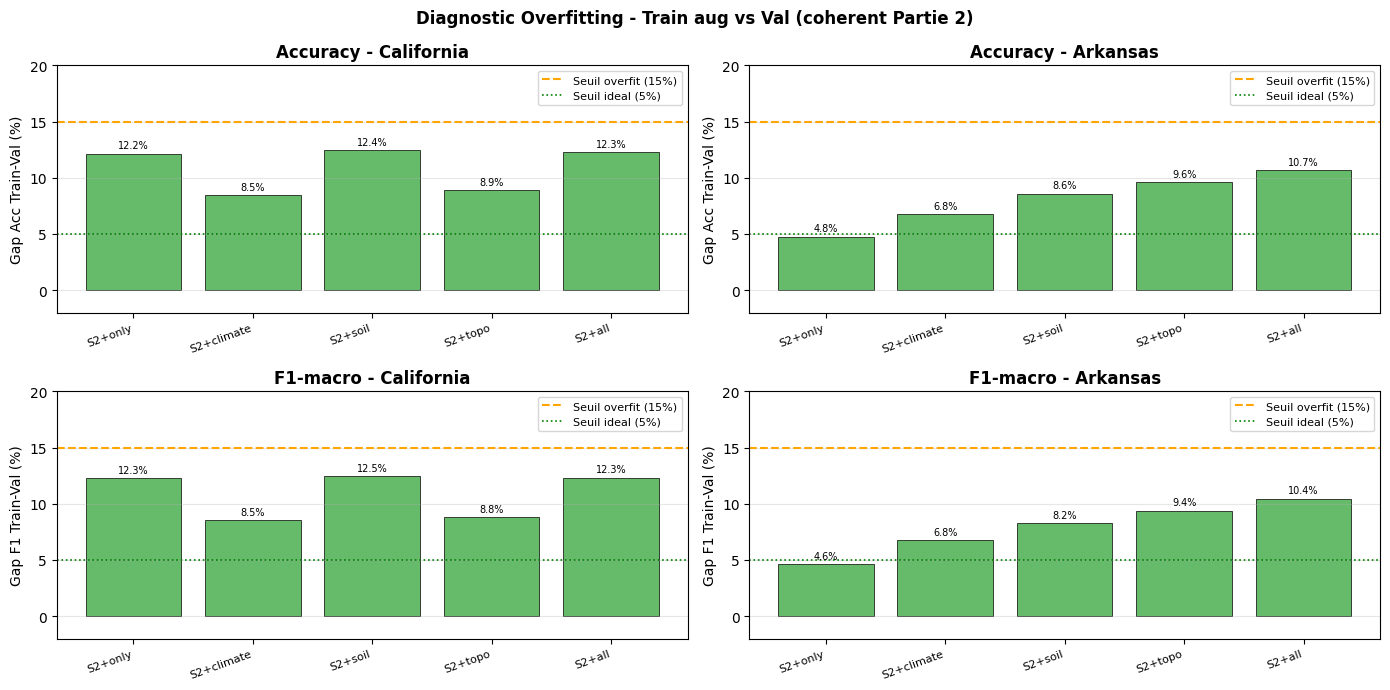

In [29]:
def plot_learning_curves(hists, region_label, configs, save_path=None):
    """3 colonnes par config : Loss / Accuracy / F1-macro.
       Trace les courbes avec aug (coherent Partie 2)."""
    n = len(configs)
    fig, axes = plt.subplots(n, 3, figsize=(18, 3.2 * n))
    if n == 1:
        axes = axes[np.newaxis, :]
    fig.suptitle(f"Courbes d apprentissage - {region_label}",
                 fontsize=13, fontweight='bold', y=1.005)

    c_tr  = '#1976D2'
    c_val = '#D32F2F'

    for i, cfg in enumerate(configs):
        h = hists[cfg]
        epochs  = list(range(1, len(h['loss']) + 1))
        best_ep = h.get('best_epoch', len(h['loss']))
        ax_l, ax_a, ax_f = axes[i, 0], axes[i, 1], axes[i, 2]
        cfg_label = cfg.replace('S2_only','S2 seul').replace('S2_','S2+')

        ax_l.plot(epochs, h['loss'],     color=c_tr,  lw=2.0, label='train loss')
        ax_l.plot(epochs, h['val_loss'], color=c_val, lw=2.0, label='val loss', linestyle='--')
        ax_l.axvline(best_ep, color='gray', lw=1.0, linestyle=':',
                     label=f'Best ep.{best_ep}')
        ax_l.fill_between(epochs, h['loss'], h['val_loss'],
                           alpha=0.08, color='purple', label='gap')
        ax_l.set_title(f'[{cfg_label}]  Loss', fontsize=9, fontweight='bold')
        ax_l.set_xlabel('Epoch', fontsize=8); ax_l.set_ylabel('Loss', fontsize=8)
        ax_l.legend(fontsize=7); ax_l.grid(True, alpha=0.25)

        gap_loss = h['val_loss'][-1] - h['loss'][-1]
        if gap_loss > 0.3:
            diag, col = 'Overfitting', 'red'
        elif h['val_loss'][-1] > 1.5:
            diag, col = 'Underfitting', 'orange'
        else:
            diag, col = 'Convergence OK', 'green'
        ax_l.text(0.02, 0.97, diag, transform=ax_l.transAxes,
                  fontsize=7.5, color=col, va='top',
                  bbox=dict(boxstyle='round,pad=0.25', fc='white', alpha=0.8))

        ax_a.plot(epochs, h['acc'],     color=c_tr,  lw=2.0, label='train acc')
        ax_a.plot(epochs, h['val_acc'], color=c_val, lw=2.0, label='val acc', linestyle='--')
        ax_a.axvline(best_ep, color='gray', lw=1.0, linestyle=':')
        ax_a.set_title(f'[{cfg_label}]  Accuracy (%)', fontsize=9, fontweight='bold')
        ax_a.set_xlabel('Epoch', fontsize=8); ax_a.set_ylabel('Accuracy (%)', fontsize=8)
        ax_a.set_ylim(0, 105)
        ax_a.legend(fontsize=7); ax_a.grid(True, alpha=0.25)

        gap_acc = h['acc'][-1] - h['val_acc'][-1]
        ax_a.text(0.02, 0.03, f'Gap train-val: {gap_acc:+.1f}%',
                  transform=ax_a.transAxes, fontsize=7.5,
                  color='red' if gap_acc > 15 else 'green',
                  bbox=dict(boxstyle='round,pad=0.25', fc='white', alpha=0.8))

        ax_f.plot(epochs, [v*100 for v in h['train_f1']], color=c_tr,  lw=2.0, label='train F1')
        ax_f.plot(epochs, [v*100 for v in h['val_f1']],   color=c_val, lw=2.0, label='val F1', linestyle='--')
        ax_f.axvline(best_ep, color='gray', lw=1.0, linestyle=':')
        ax_f.fill_between(epochs,
                          [v*100 for v in h['train_f1']],
                          [v*100 for v in h['val_f1']],
                          alpha=0.08, color='green')
        best_vf1 = h['val_f1'][best_ep - 1] * 100
        ax_f.axhline(best_vf1, color='green', lw=0.8, linestyle='-.', alpha=0.6,
                     label=f'Best val F1={best_vf1:.1f}%')
        ax_f.set_title(f'[{cfg_label}]  F1-macro (%)', fontsize=9, fontweight='bold')
        ax_f.set_xlabel('Epoch', fontsize=8); ax_f.set_ylabel('F1-macro (%)', fontsize=8)
        ax_f.set_ylim(0, 105)
        ax_f.legend(fontsize=7); ax_f.grid(True, alpha=0.25)

        gap_f1 = (h['train_f1'][-1] - h['val_f1'][-1]) * 100
        ax_f.text(0.02, 0.03, f'Gap F1 train-val: {gap_f1:+.1f}%',
                  transform=ax_f.transAxes, fontsize=7.5,
                  color='red' if gap_f1 > 15 else 'green',
                  bbox=dict(boxstyle='round,pad=0.25', fc='white', alpha=0.8))

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_overfitting_summary(hists_CA, hists_AR, configs):
    """Synthese : gap train_aug - val (coherent Partie 2)."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 7))
    x = np.arange(len(configs))
    labels = [c.replace('S2_','S2+').replace('_only',' seul') for c in configs]
    metrics = [
        ('acc',      'val_acc', 'Accuracy', 'Gap Acc Train-Val (%)'),
        ('train_f1', 'val_f1',  'F1-macro', 'Gap F1 Train-Val (%)'),
    ]
    for row, (tr_key, va_key, mname, ylabel) in enumerate(metrics):
        for col, (hists, region) in enumerate([(hists_CA, 'California'), (hists_AR, 'Arkansas')]):
            ax = axes[row, col]
            gaps = []
            for c in configs:
                h = hists[c]
                tr = h[tr_key][-1] * (100 if 'f1' in tr_key else 1)
                va = h[va_key][-1] * (100 if 'f1' in va_key else 1)
                gaps.append(tr - va)
            bars = ax.bar(x, gaps,
                          color=['#EF5350' if g > 15 else '#66BB6A' for g in gaps],
                          edgecolor='black', linewidth=0.5)
            ax.axhline(15, color='orange', linestyle='--', lw=1.5, label='Seuil overfit (15%)')
            ax.axhline(5,  color='green',  linestyle=':',  lw=1.2, label='Seuil ideal (5%)')
            ax.set_xticks(x); ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=8)
            ax.set_ylabel(ylabel); ax.set_title(f'{mname} - {region}', fontweight='bold')
            ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')
            ax.set_ylim(min(min(gaps) * 1.2, -2), max(max(gaps) * 1.35, 20))
            for bar, g in zip(bars, gaps):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                        f'{g:.1f}%', ha='center', va='bottom', fontsize=7)
    plt.suptitle('Diagnostic Overfitting - Train aug vs Val (coherent Partie 2)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(PROCESSED_DIR / 'overfitting_summary_NEW.png', dpi=150, bbox_inches='tight')
    plt.show()


print('=== Courbes - CALIFORNIA ===')
plot_learning_curves(hists_CA, 'California', CONFIGS,
                     save_path=PROCESSED_DIR / 'learning_curves_CA_NEW.png')

print('\n=== Courbes - ARKANSAS ===')
plot_learning_curves(hists_AR, 'Arkansas', CONFIGS,
                     save_path=PROCESSED_DIR / 'learning_curves_AR_NEW.png')

print('\n=== Synthese Overfitting ===')
plot_overfitting_summary(hists_CA, hists_AR, CONFIGS)


## Tableau comparatif (Ablation Study)


=== Ablation Study - Resultats (MS-SE-BiGRU-Attn) ===
Configuration CA - OA (%) CA - Kappa CA - F1 AR - OA (%) AR - Kappa AR - F1
      S2 only       81.94      0.762   0.744       77.21      0.681   0.714
   S2 climate       81.76      0.760   0.743       79.19      0.706   0.732
      S2 soil       81.01      0.752   0.726       79.58      0.709   0.742
      S2 topo       83.59      0.783   0.759       78.84      0.700   0.731
       S2 all       84.84      0.798   0.777       81.32      0.729   0.752


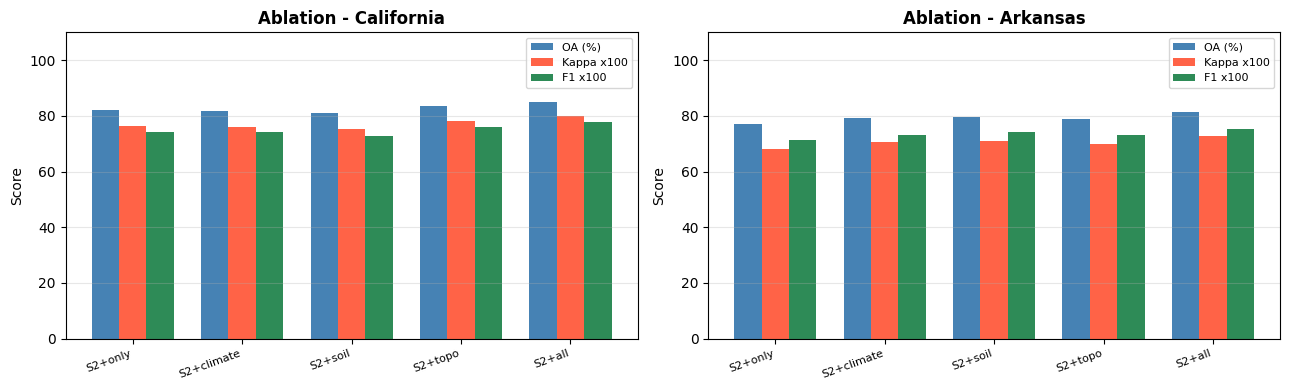

In [20]:
def plot_ablation_table(results_CA, results_AR, configs):
    rows = []
    for cfg in configs:
        ca = results_CA[cfg]
        ar = results_AR[cfg]
        rows.append({
            'Configuration': cfg.replace('_', ' '),
            'CA - OA (%)' : f"{ca['OA']:.2f}",
            'CA - Kappa'  : f"{ca['Kappa']:.3f}",
            'CA - F1'     : f"{ca['F1']:.3f}",
            'AR - OA (%)' : f"{ar['OA']:.2f}",
            'AR - Kappa'  : f"{ar['Kappa']:.3f}",
            'AR - F1'     : f"{ar['F1']:.3f}",
        })
    df = pd.DataFrame(rows)
    print('\n=== Ablation Study - Resultats (MS-SE-BiGRU-Attn) ===')
    print(df.to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    x = np.arange(len(configs))
    labels = [c.replace('S2_', 'S2+').replace('_only', ' seul') for c in configs]
    w = 0.25

    for ax, res, region in zip(axes, [results_CA, results_AR], ['California', 'Arkansas']):
        oa    = [res[c]['OA']        for c in configs]
        kappa = [res[c]['Kappa']*100 for c in configs]
        f1    = [res[c]['F1']*100    for c in configs]
        ax.bar(x - w, oa,    w, label='OA (%)',    color='steelblue')
        ax.bar(x,     kappa, w, label='Kappa x100', color='tomato')
        ax.bar(x + w, f1,    w, label='F1 x100',   color='seagreen')
        ax.set_xticks(x); ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=8)
        ax.set_ylabel('Score'); ax.set_title(f'Ablation - {region}', fontweight='bold')
        ax.legend(fontsize=8); ax.set_ylim(0, 110); ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(PROCESSED_DIR / 'ablation_study_NEW.png', dpi=150, bbox_inches='tight')
    plt.show()
    return df


df_ablation_NEW = plot_ablation_table(results_CA, results_AR, CONFIGS)


## Matrices de confusion (S2_only vs meilleure config)

Meilleure config CA : S2_all  (Kappa=0.798)
Meilleure config AR : S2_all  (Kappa=0.729)


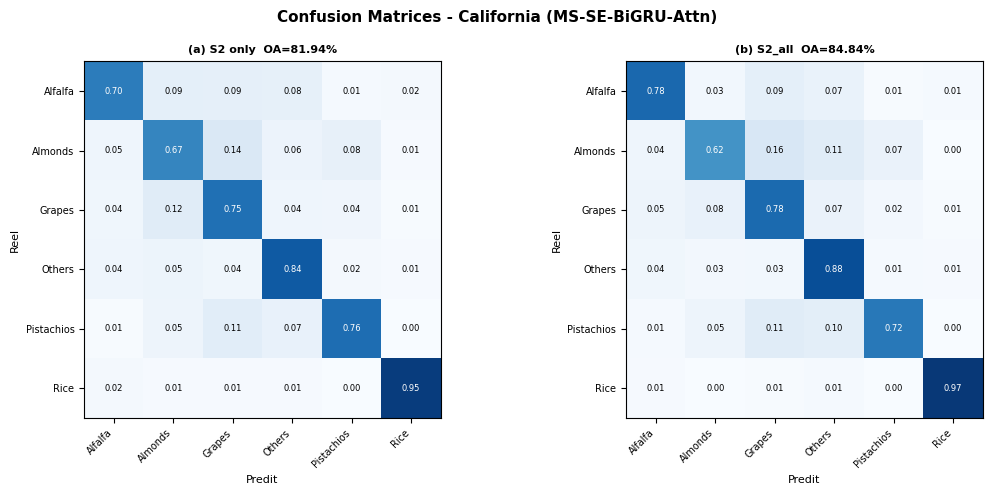

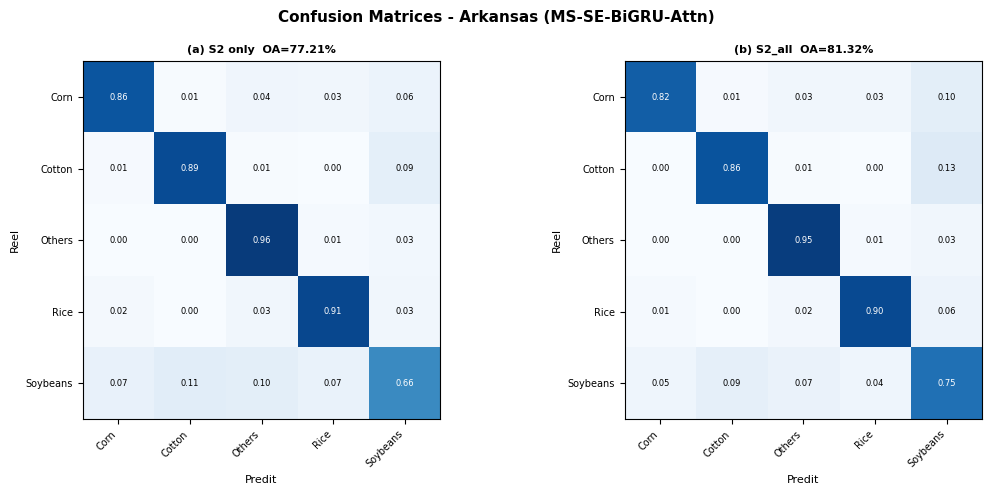

In [21]:
def plot_confusion_matrix(y_true, y_pred, classes, title='', ax=None):
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    n  = len(classes)
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4.5))
    ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(n)); ax.set_xticklabels(classes, fontsize=7, rotation=45, ha='right')
    ax.set_yticks(range(n)); ax.set_yticklabels(classes, fontsize=7)
    ax.set_xlabel('Predit', fontsize=8); ax.set_ylabel('Reel', fontsize=8)
    ax.set_title(title, fontsize=8, fontweight='bold')
    for i in range(n):
        for j in range(n):
            c = 'white' if cm[i, j] > 0.5 else 'black'
            ax.text(j, i, f'{cm[i,j]:.2f}', ha='center', va='center', fontsize=6, color=c)


best_ca = max(CONFIGS, key=lambda c: results_CA[c]['Kappa'])
best_ar = max(CONFIGS, key=lambda c: results_AR[c]['Kappa'])
print(f'Meilleure config CA : {best_ca}  (Kappa={results_CA[best_ca]["Kappa"]:.3f})')
print(f'Meilleure config AR : {best_ar}  (Kappa={results_AR[best_ar]["Kappa"]:.3f})')

# California
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
plot_confusion_matrix(
    results_CA['S2_only']['y_true'], results_CA['S2_only']['pred'],
    le_CA.classes_,
    title=f'(a) S2 only  OA={results_CA["S2_only"]["OA"]:.2f}%', ax=axes[0])
plot_confusion_matrix(
    results_CA[best_ca]['y_true'], results_CA[best_ca]['pred'],
    le_CA.classes_,
    title=f'(b) {best_ca}  OA={results_CA[best_ca]["OA"]:.2f}%', ax=axes[1])
plt.suptitle('Confusion Matrices - California (MS-SE-BiGRU-Attn)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'confusion_ca_NEW.png', dpi=150, bbox_inches='tight')
plt.show()

# Arkansas
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
plot_confusion_matrix(
    results_AR['S2_only']['y_true'], results_AR['S2_only']['pred'],
    le_AR.classes_,
    title=f'(a) S2 only  OA={results_AR["S2_only"]["OA"]:.2f}%', ax=axes[0])
plot_confusion_matrix(
    results_AR[best_ar]['y_true'], results_AR[best_ar]['pred'],
    le_AR.classes_,
    title=f'(b) {best_ar}  OA={results_AR[best_ar]["OA"]:.2f}%', ax=axes[1])
plt.suptitle('Confusion Matrices - Arkansas (MS-SE-BiGRU-Attn)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'confusion_ar_NEW.png', dpi=150, bbox_inches='tight')
plt.show()


## Grad-CAM : Visualisation des features importantes 


--- Grad-CAM : California - S2_only ---


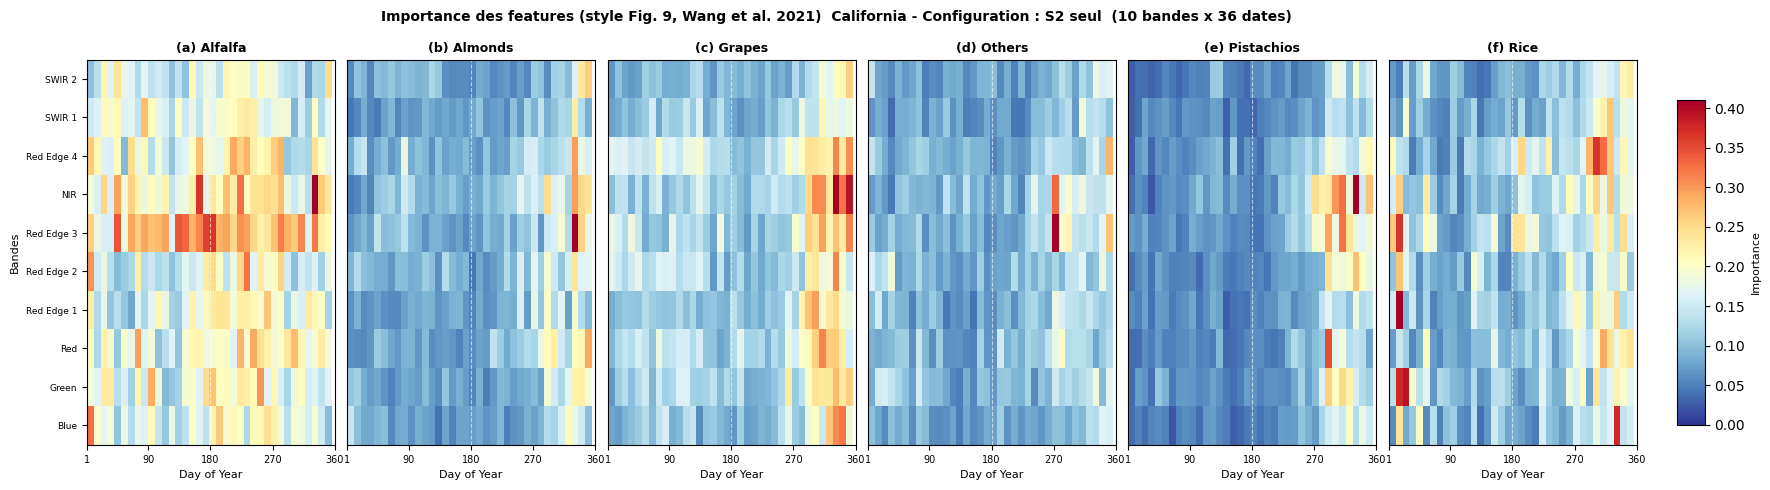


--- Grad-CAM : California - S2_all ---


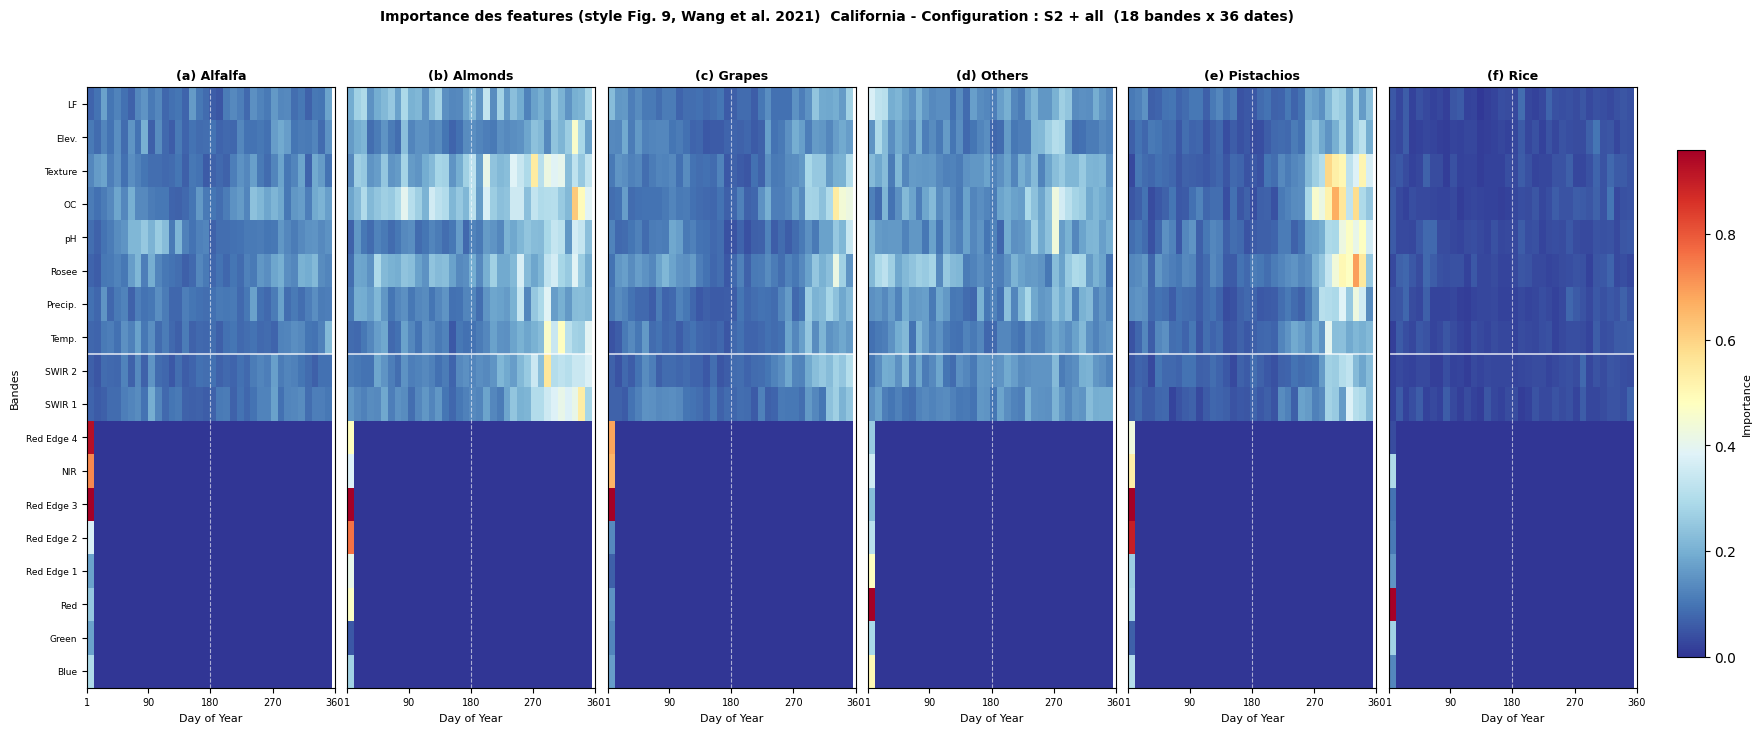


--- Grad-CAM : Arkansas - S2_only ---


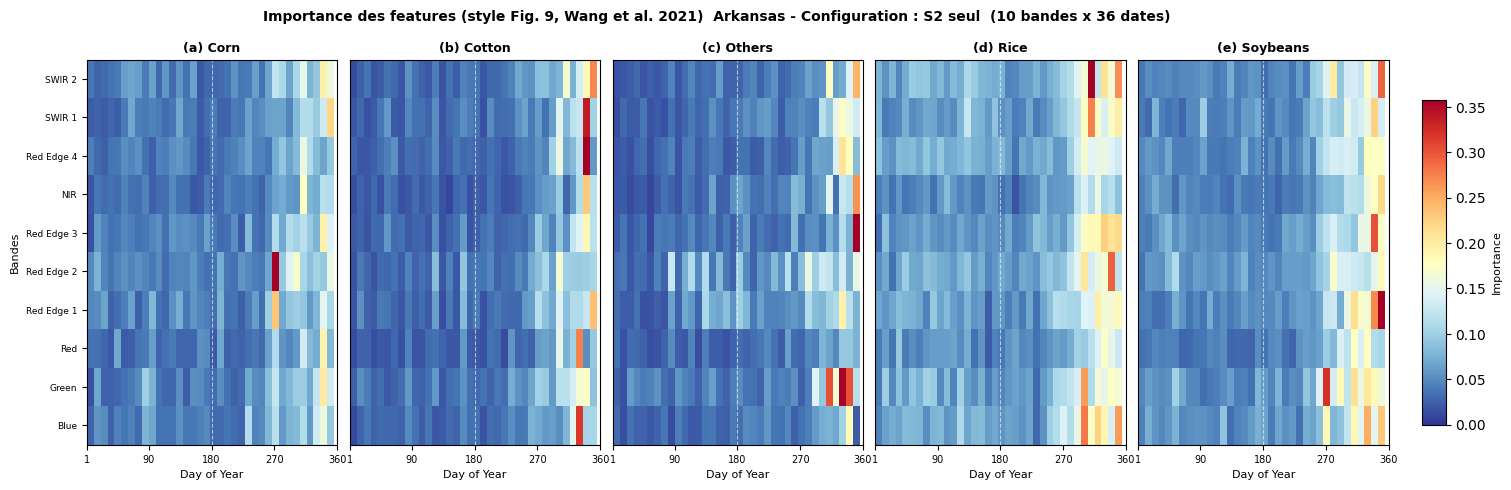


--- Grad-CAM : Arkansas - S2_all ---


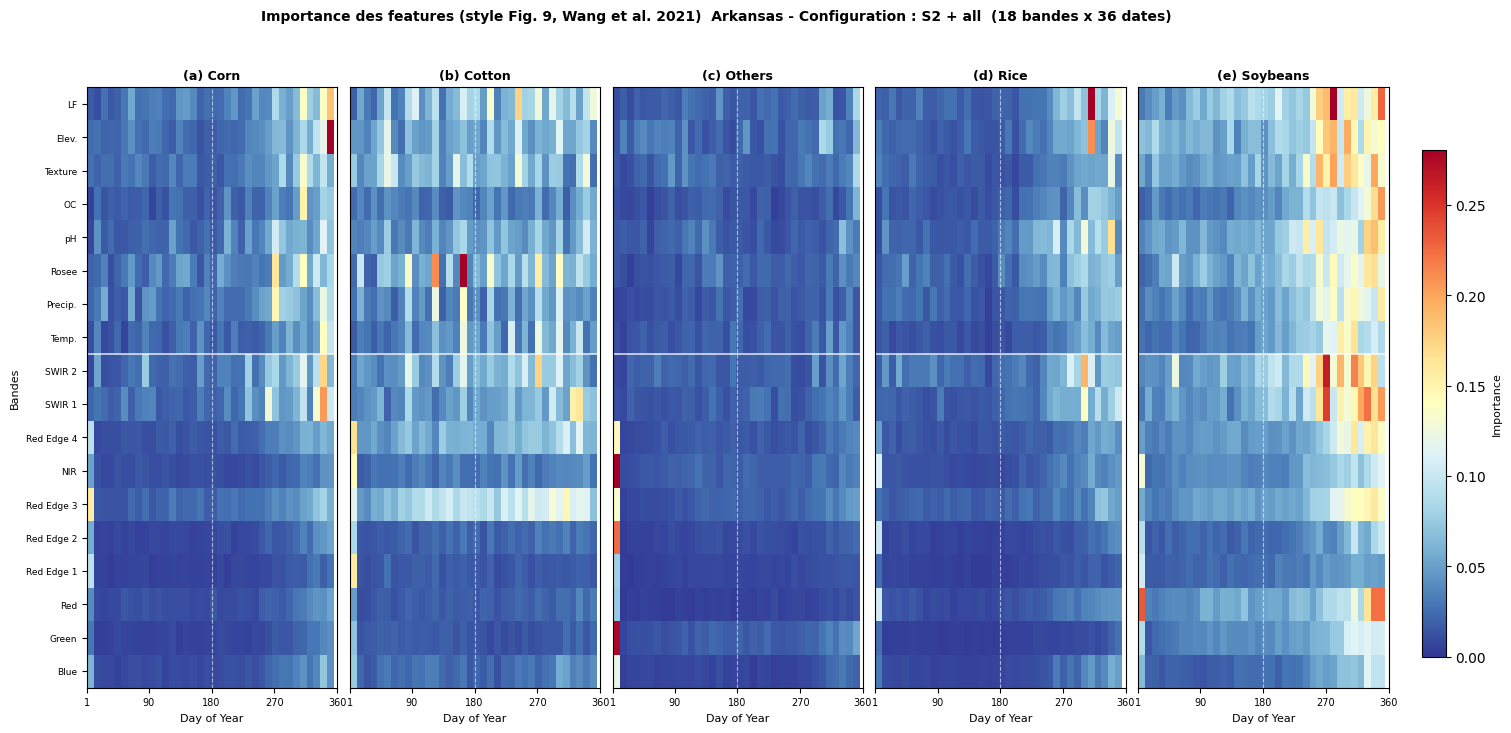

In [22]:
import torch.nn.functional as F

S2_BASE_BANDS = ['Blue', 'Green', 'Red', 'Red Edge 1', 'Red Edge 2', 'Red Edge 3',
                  'NIR', 'Red Edge 4', 'SWIR 1', 'SWIR 2']
EXTRA_BANDS = {
    'S2_only'   : [],
    'S2_climate': ['Temperature', 'Precip.', 'Point rosee'],
    'S2_soil'   : ['pH', 'Carb. org.', 'Texture'],
    'S2_topo'   : ['Elevation', 'Landforms'],
    'S2_all'    : ['Temp.', 'Precip.', 'Rosee', 'pH', 'OC', 'Texture', 'Elev.', 'LF'],
}

def get_band_names(config_name):
    return S2_BASE_BANDS + EXTRA_BANDS.get(config_name, [])


def compute_gradcam_per_class(model, datasets, config_name, device,
                               le, n_samples_per_class=50):
    d             = datasets[config_name]
    n_bands_total = d['n_bands_total']
    X_test        = d['X_test']
    y_test        = d['y_test']

    grad_cam_dict = {}
    model.eval()

    for cls_idx, cls_name in enumerate(le.classes_):
        mask  = (y_test == cls_idx)
        X_cls = X_test[mask][:n_samples_per_class]
        if len(X_cls) == 0:
            continue
        cam_accum = np.zeros((N_DATES, n_bands_total), dtype=np.float32)
        for i in range(len(X_cls)):
            x = torch.from_numpy(X_cls[i:i+1]).to(device).float()
            x.requires_grad_(True)
            logits = model(x)
            score  = logits[0, cls_idx]
            model.zero_grad()
            score.backward()
            grad_inp = x.grad.cpu().numpy()[0]
            inp_val  = X_cls[i]
            saliency = np.abs(grad_inp * inp_val)
            saliency = saliency.reshape(N_DATES, n_bands_total)
            saliency /= (saliency.max() + 1e-8)
            cam_accum += saliency
        grad_cam_dict[cls_name] = cam_accum / max(len(X_cls), 1)
    return grad_cam_dict


def plot_gradcam_figure9(grad_cam_dict, config_name, region_label,
                          n_bands_total, save_path=None):
    band_names = get_band_names(config_name)[:n_bands_total]
    classes    = list(grad_cam_dict.keys())
    n_cls      = len(classes)
    doy_axis   = [int(i * 365 / N_DATES) + 1 for i in range(N_DATES)]
    fig_h      = max(4.0, n_bands_total * 0.35 + 1.5)
    fig, axes  = plt.subplots(1, n_cls, figsize=(3.2 * n_cls + 0.8, fig_h), squeeze=False)
    title_cfg  = config_name.replace('S2_only', 'S2 seul').replace('S2_', 'S2 + ')
    fig.suptitle(
        f'Importance des features (style Fig. 9, Wang et al. 2021)  '
        f'{region_label} - Configuration : {title_cfg}  '
        f'({n_bands_total} bandes x {N_DATES} dates)',
        fontsize=10, fontweight='bold'
    )
    im_ref = None
    for j, cls_name in enumerate(classes):
        ax = axes[0, j]
        cam_T = grad_cam_dict[cls_name].T
        im = ax.imshow(cam_T, aspect='auto', cmap='RdYlBu_r',
                       vmin=0, vmax=cam_T.max(),
                       extent=[doy_axis[0], doy_axis[-1], -0.5, n_bands_total - 0.5])
        im_ref = im
        ax.set_title(f'({chr(97 + j)}) {cls_name}', fontsize=9, fontweight='bold')
        ax.set_xlabel('Day of Year', fontsize=8)
        if j == 0:
            ax.set_ylabel('Bandes', fontsize=8)
            ax.set_yticks(range(n_bands_total))
            ax.set_yticklabels(band_names, fontsize=6.5)
        else:
            ax.set_yticks([])
        ax.set_xticks([1, 90, 180, 270, 360])
        ax.set_xticklabels(['1', '90', '180', '270', '360'], fontsize=7)
        ax.axvline(180, color='white', linestyle='--', lw=0.8, alpha=0.6)
        if n_bands_total > 10:
            ax.axhline(9.5, color='white', linestyle='-', lw=1.2, alpha=0.8)
    if im_ref is not None:
        cbar_ax = fig.add_axes([0.92, 0.15, 0.014, 0.65])
        cb = fig.colorbar(im_ref, cax=cbar_ax)
        cb.set_label('Importance', fontsize=8)
    plt.subplots_adjust(right=0.90, wspace=0.05)
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


# Calcule Grad-CAM pour S2_only et S2_all sur CA + AR
for region, datasets_d, models_d, le_d in [
    ('California', datasets_CA, models_CA, le_CA),
    ('Arkansas',   datasets_AR, models_AR, le_AR),
]:
    for cfg in ['S2_only', 'S2_all']:
        print(f'\n--- Grad-CAM : {region} - {cfg} ---')
        n_bands_total = datasets_d[cfg]['n_bands_total']
        cam = compute_gradcam_per_class(
            models_d[cfg], datasets_d, cfg, DEVICE, le_d, n_samples_per_class=50)
        plot_gradcam_figure9(
            cam, cfg, region, n_bands_total,
            save_path=PROCESSED_DIR / f'gradcam_{region[:2].upper()}_{cfg}_NEW.png',
        )


## Cartes True / Predicted / Residual - Section B (style Fig. 9-10 paper)

>
### Strategie

On compare visuellement les 2 configs extremes pour chaque zone :
- **`S2_only`** : baseline sans covariables
- **Meilleure config par Kappa** : la config qui maximise la performance

### 3 panneaux par carte

- **True Map** : vraies classes (couleurs CDL standard)
- **Predicted Map** : classes predites par notre modele
- **Residual Map** : blanc = correct, noir = erreur



Meilleure config CA : S2_all  (Kappa=0.798)
Meilleure config AR : S2_all  (Kappa=0.729)

CALIFORNIA - S2_only
  Sauvegarde : data\processed\cropmap_CA_sectionB_S2_only.png


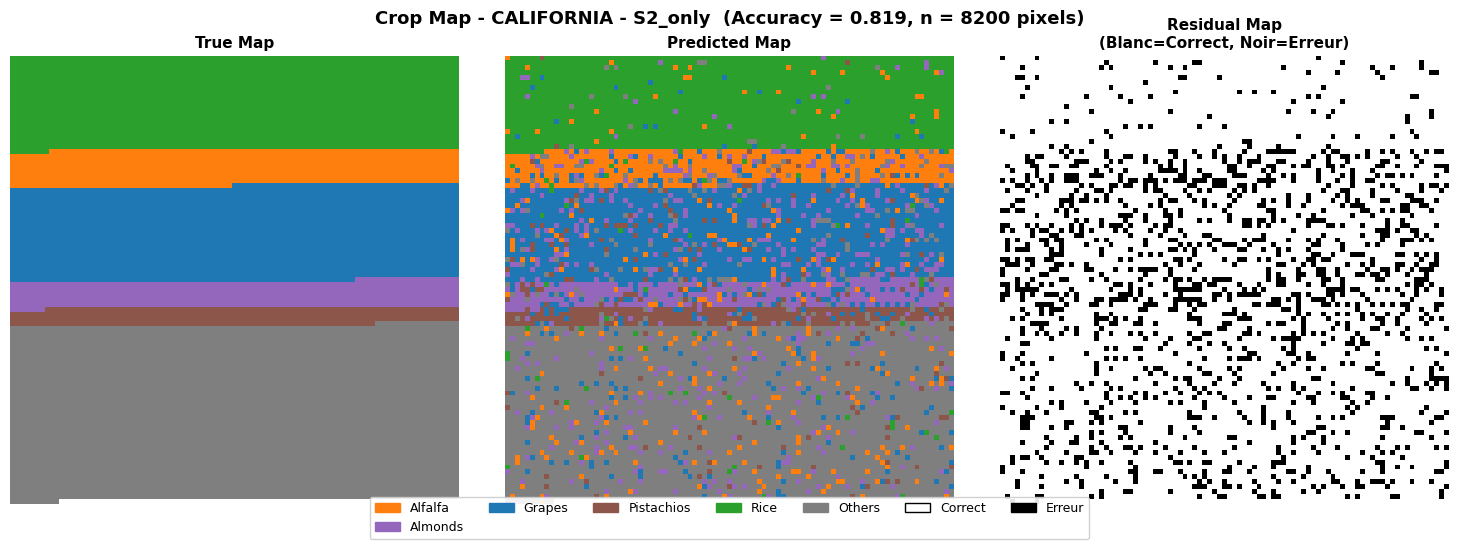

CALIFORNIA - S2_all (meilleure config)
  Sauvegarde : data\processed\cropmap_CA_sectionB_S2_all.png


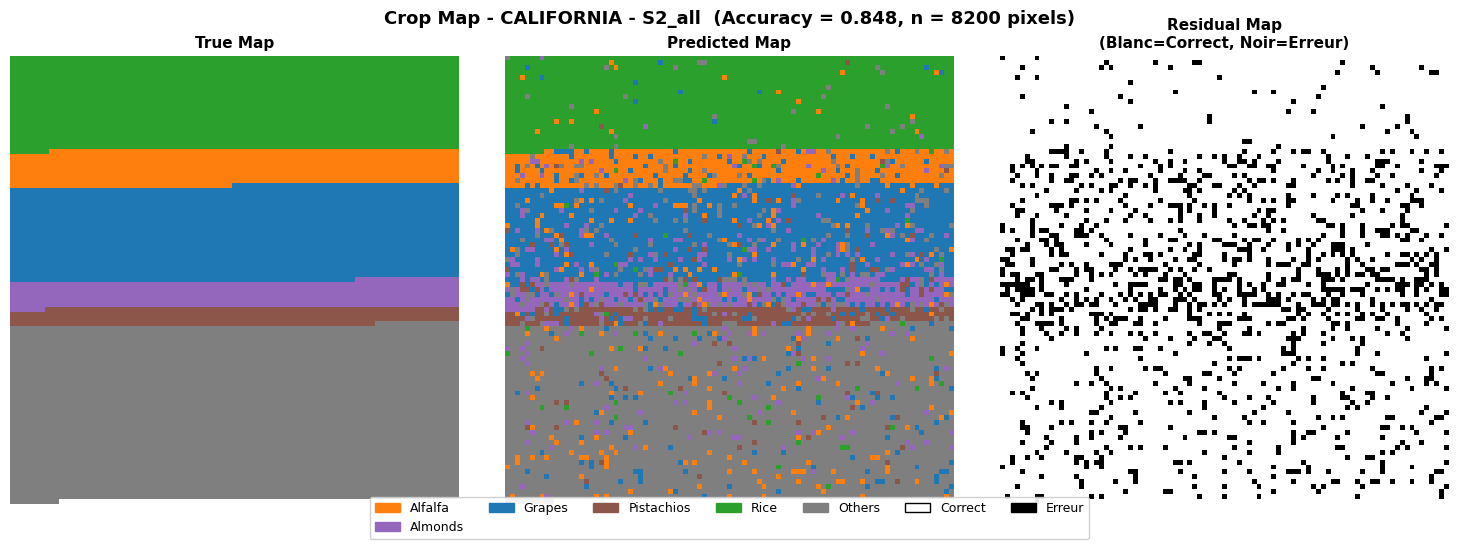

ARKANSAS - S2_only
  Sauvegarde : data\processed\cropmap_AR_sectionB_S2_only.png


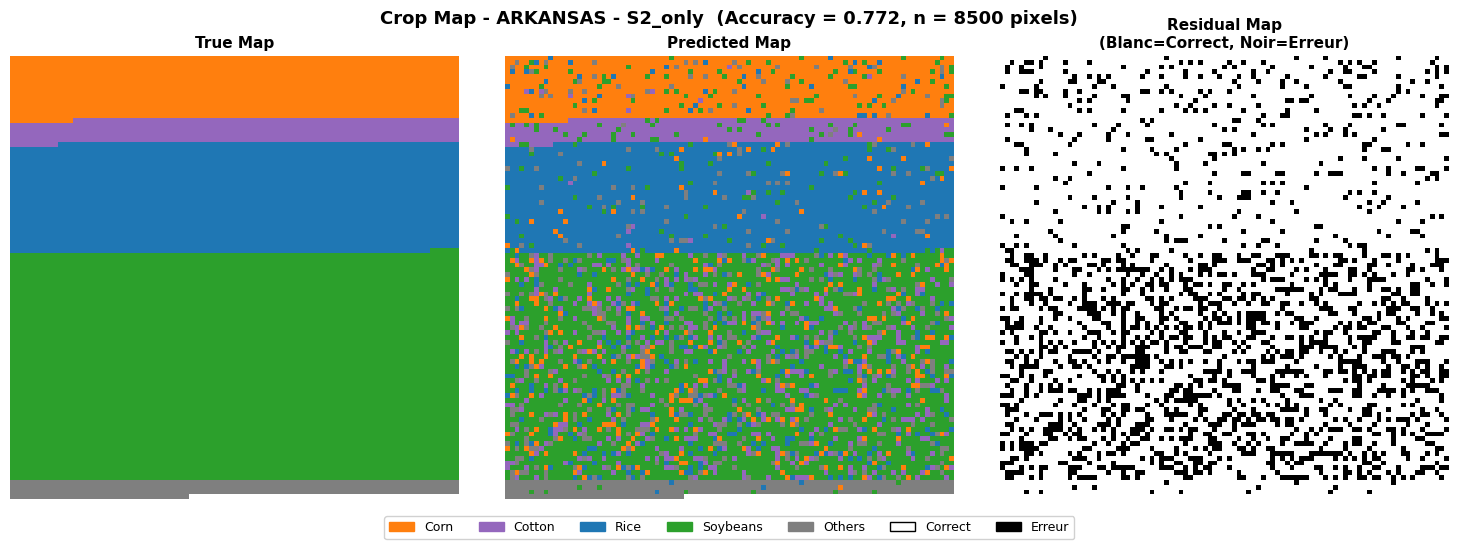

ARKANSAS - S2_all (meilleure config)
  Sauvegarde : data\processed\cropmap_AR_sectionB_S2_all.png


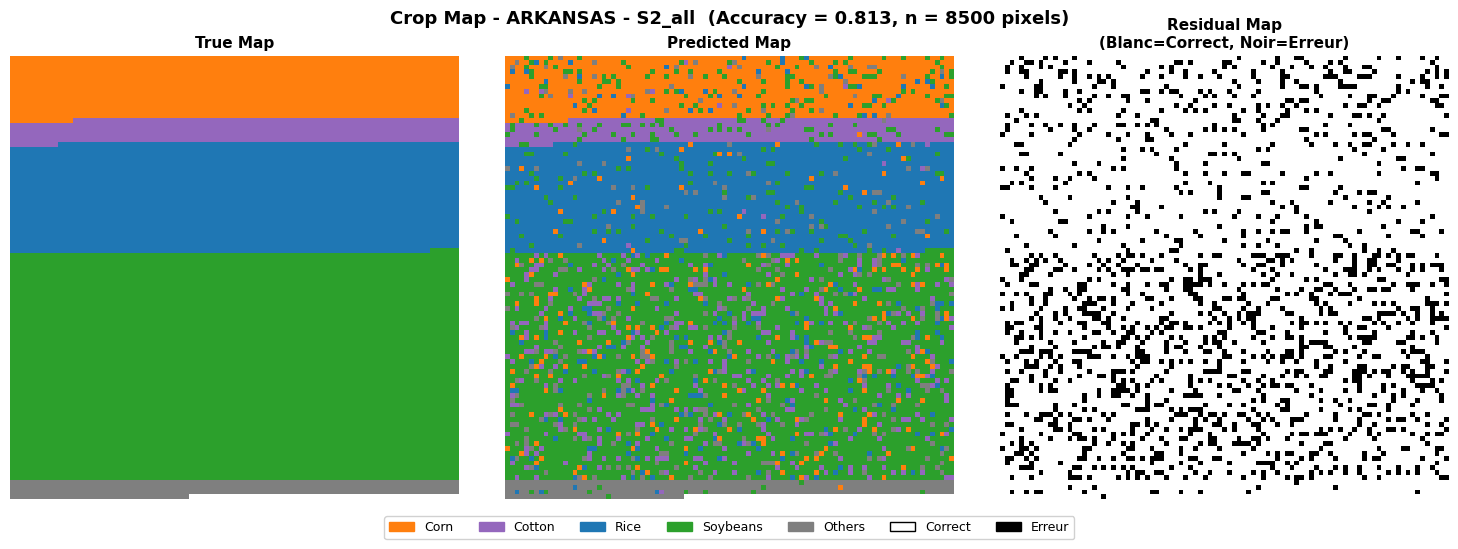

In [23]:
import matplotlib.patches as mpatches

# Couleurs CDL standard (memes que Section A pour coherence)
CA_CROP_COLORS = {
    'Grapes':'#1f77b4', 'Rice':'#2ca02c', 'Alfalfa':'#ff7f0e',
    'Almonds':'#9467bd', 'Pistachios':'#8c564b', 'Others':'#7f7f7f',
}
AR_CROP_COLORS = {
    'Soybeans':'#2ca02c', 'Rice':'#1f77b4', 'Corn':'#ff7f0e',
    'Cotton':'#9467bd', 'Others':'#7f7f7f',
}


def _labels_to_rgb_grid(labels_enc, classes_list, color_map):
    """Convertit (N,) labels encodes en image RGB (h, w, 3) en grille carree."""
    n_pix = len(labels_enc)
    h = w = int(np.ceil(np.sqrt(n_pix)))
    img = np.ones((h * w, 3), dtype=np.float32)
    for i, enc in enumerate(labels_enc):
        cls = classes_list[enc]
        hex_c = color_map.get(cls, '#cccccc')
        r = int(hex_c[1:3], 16) / 255
        g = int(hex_c[3:5], 16) / 255
        b = int(hex_c[5:7], 16) / 255
        img[i] = [r, g, b]
    return img.reshape(h, w, 3)


def simulate_crop_map_B(y_true, y_pred, classes_list, color_map, label,
                         order=None, save_path=None):
    """Carte True/Predicted/Residual style Fig. 9-10 du paper.
       Pixels arranges en grille carree (pas de coords geo dans CSV)."""
    n_pix = len(y_true)
    h = w = int(np.ceil(np.sqrt(n_pix)))

    img_true = _labels_to_rgb_grid(y_true, classes_list, color_map)
    img_pred = _labels_to_rgb_grid(y_pred, classes_list, color_map)

    residual = np.ones((h * w, 3), dtype=np.float32)
    for i in range(n_pix):
        if y_true[i] != y_pred[i]:
            residual[i] = [0, 0, 0]
    residual = residual.reshape(h, w, 3)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5.2))
    axes[0].imshow(img_true);  axes[0].set_title('True Map',      fontsize=11, fontweight='bold')
    axes[1].imshow(img_pred);  axes[1].set_title('Predicted Map', fontsize=11, fontweight='bold')
    axes[2].imshow(residual);  axes[2].set_title('Residual Map\n(Blanc=Correct, Noir=Erreur)',
                                                 fontsize=11, fontweight='bold')
    for ax in axes:
        ax.axis('off')

    if order is None:
        order = sorted(classes_list)
    patches = [mpatches.Patch(color=color_map.get(c, '#ccc'), label=c)
               for c in order if c in classes_list]
    patches += [mpatches.Patch(color='white', label='Correct', ec='black'),
                mpatches.Patch(color='black', label='Erreur')]
    fig.legend(handles=patches, loc='lower center', ncol=min(len(patches), 7),
               bbox_to_anchor=(0.5, -0.05), fontsize=9, framealpha=0.9)

    pct_correct = (y_true == y_pred).mean()
    plt.suptitle(f'Crop Map - {label}  '
                 f'(Accuracy = {pct_correct:.3f}, n = {n_pix} pixels)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'  Sauvegarde : {save_path}')
    plt.show()


# === Identifier meilleure config par zone =====================================
best_ca = max(CONFIGS, key=lambda c: results_CA[c]['Kappa'])
best_ar = max(CONFIGS, key=lambda c: results_AR[c]['Kappa'])
print(f'Meilleure config CA : {best_ca}  (Kappa={results_CA[best_ca]["Kappa"]:.3f})')
print(f'Meilleure config AR : {best_ar}  (Kappa={results_AR[best_ar]["Kappa"]:.3f})')
print()


# === CALIFORNIA - S2_only + meilleure config ==================================
ca_order = ['Alfalfa','Almonds','Grapes','Pistachios','Rice','Others']

print('=' * 50)
print('CALIFORNIA - S2_only')
print('=' * 50)
res = results_CA['S2_only']
simulate_crop_map_B(
    y_true=res['y_true'], y_pred=res['pred'],
    classes_list=list(le_CA.classes_),
    color_map=CA_CROP_COLORS, label='CALIFORNIA - S2_only',
    order=ca_order,
    save_path=PROCESSED_DIR / 'cropmap_CA_sectionB_S2_only.png',
)

print('=' * 50)
print(f'CALIFORNIA - {best_ca} (meilleure config)')
print('=' * 50)
res = results_CA[best_ca]
simulate_crop_map_B(
    y_true=res['y_true'], y_pred=res['pred'],
    classes_list=list(le_CA.classes_),
    color_map=CA_CROP_COLORS, label=f'CALIFORNIA - {best_ca}',
    order=ca_order,
    save_path=PROCESSED_DIR / f'cropmap_CA_sectionB_{best_ca}.png',
)


# === ARKANSAS - S2_only + meilleure config ====================================
ar_order = ['Corn','Cotton','Rice','Soybeans','Others']

print('=' * 50)
print('ARKANSAS - S2_only')
print('=' * 50)
res = results_AR['S2_only']
simulate_crop_map_B(
    y_true=res['y_true'], y_pred=res['pred'],
    classes_list=list(le_AR.classes_),
    color_map=AR_CROP_COLORS, label='ARKANSAS - S2_only',
    order=ar_order,
    save_path=PROCESSED_DIR / 'cropmap_AR_sectionB_S2_only.png',
)

print('=' * 50)
print(f'ARKANSAS - {best_ar} (meilleure config)')
print('=' * 50)
res = results_AR[best_ar]
simulate_crop_map_B(
    y_true=res['y_true'], y_pred=res['pred'],
    classes_list=list(le_AR.classes_),
    color_map=AR_CROP_COLORS, label=f'ARKANSAS - {best_ar}',
    order=ar_order,
    save_path=PROCESSED_DIR / f'cropmap_AR_sectionB_{best_ar}.png',
)


## Sauvegarde des resultats

## Visualisation des gains : Section B (NEW) vs Partie 2


1. **Bar chart Section B vs Partie 2** : OA cote a cote pour chaque config x zone
2. **Bar chart Delta OA** : gain ou perte vs Partie 2 (vert = on bat MCTNet, rouge = on perd)
3. **Heatmap Δ par config x zone** : vue synthetique des 10 cas (5 configs x 2 zones)
4. **Tableau recap CSV** exporte pour le rapport

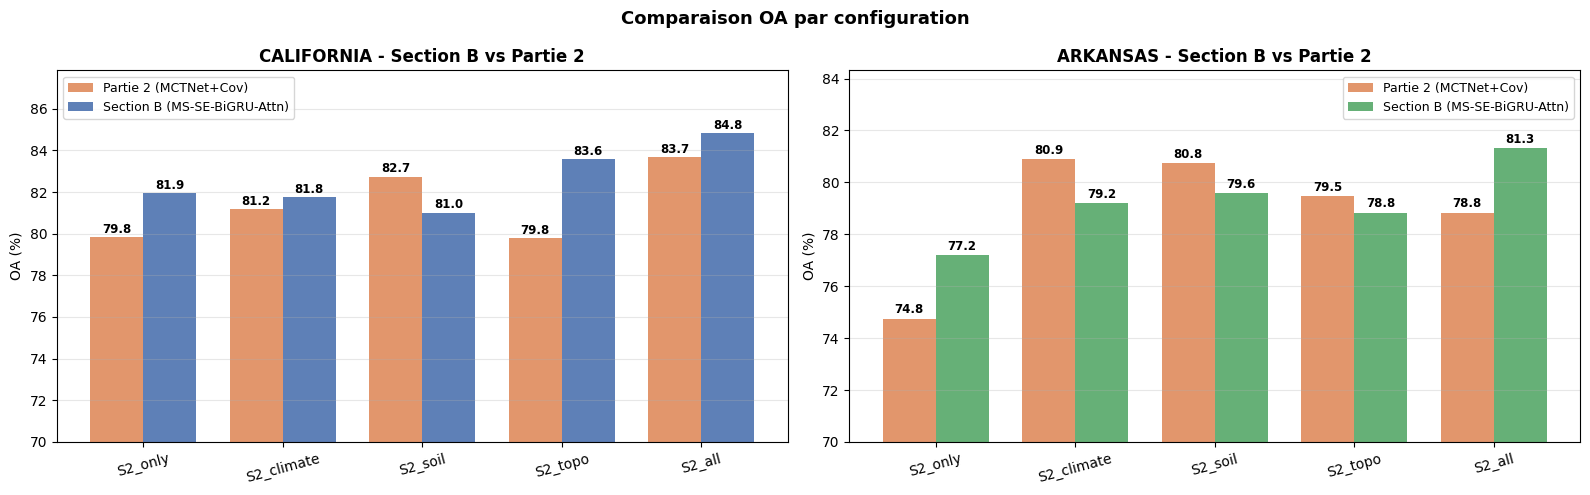

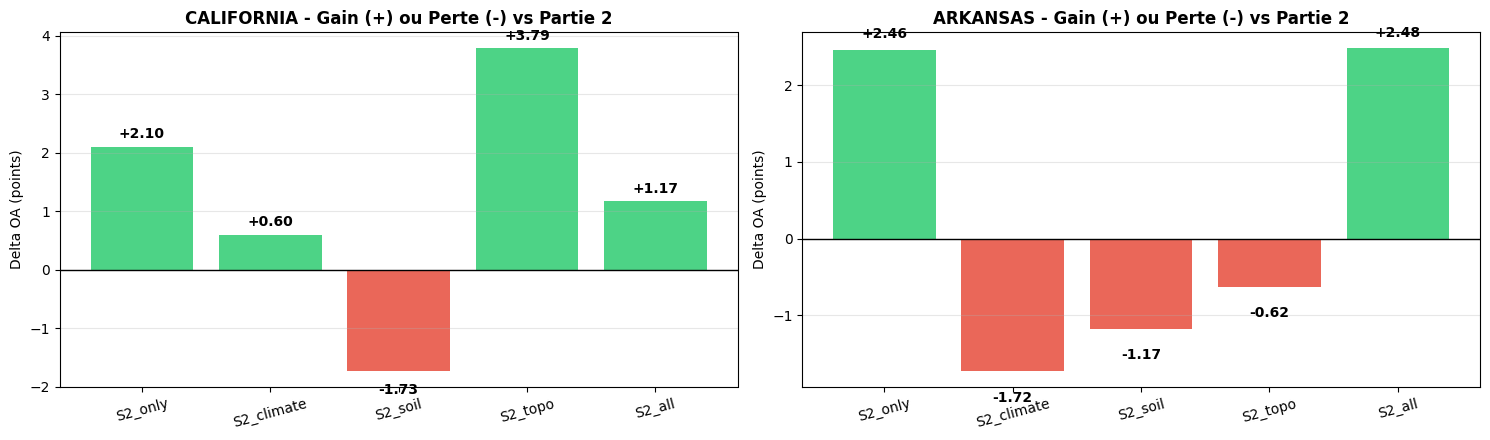

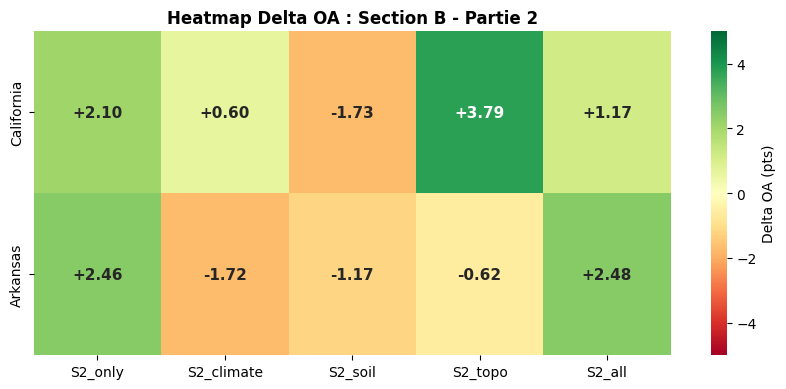


=== Tableau recap Section B vs Partie 2 ===
      Zone     Config P2 OA NEW OA Delta OA P2 Kappa NEW Kappa Delta K P2 F1 NEW F1 Delta F1
CALIFORNIA    S2_only 79.84  81.94    +2.10    0.735     0.762  +0.027 0.718  0.744   +0.026
CALIFORNIA S2_climate 81.16  81.76    +0.60    0.754     0.760  +0.006 0.737  0.743   +0.006
CALIFORNIA    S2_soil 82.74  81.01    -1.73    0.771     0.752  -0.019 0.746  0.726   -0.020
CALIFORNIA    S2_topo 79.80  83.59    +3.79    0.737     0.783  +0.046 0.725  0.759   +0.034
CALIFORNIA     S2_all 83.67  84.84    +1.17    0.784     0.798  +0.014 0.760  0.777   +0.017
  ARKANSAS    S2_only 74.75  77.21    +2.46    0.646     0.681  +0.035 0.690  0.714   +0.024
  ARKANSAS S2_climate 80.91  79.19    -1.72    0.725     0.706  -0.019 0.749  0.732   -0.017
  ARKANSAS    S2_soil 80.75  79.58    -1.17    0.723     0.709  -0.014 0.747  0.742   -0.005
  ARKANSAS    S2_topo 79.46  78.84    -0.62    0.703     0.700  -0.003 0.744  0.731   -0.013
  ARKANSAS     S2_all 78.

In [ ]:

P2_CA = {
    'S2_only'   : {'OA':  79.84 , 'Kappa': 0.735, 'F1': 0.718},
    'S2_climate': {'OA': 81.16, 'Kappa': 0.754, 'F1': 0.737},
    'S2_soil'   : {'OA': 82.74, 'Kappa': 0.771, 'F1': 0.746},
    'S2_topo'   : {'OA': 79.80, 'Kappa': 0.737, 'F1': 0.725},
    'S2_all'    : {'OA': 83.67, 'Kappa': 0.784, 'F1': 0.760},
}
P2_AR = {
    'S2_only'   : {'OA': 74.75, 'Kappa': 0.646, 'F1': 0.690},
    'S2_climate': {'OA': 80.91, 'Kappa': 0.725, 'F1': 0.749},
    'S2_soil'   : {'OA': 80.75, 'Kappa': 0.723, 'F1': 0.747},
    'S2_topo'   : {'OA': 79.46, 'Kappa': 0.703, 'F1': 0.744},
    'S2_all'    : {'OA': 78.84, 'Kappa': 0.699, 'F1': 0.744},
}

NEW_CA_b = {cfg: {'OA': results_CA[cfg]['OA'],
                   'Kappa': results_CA[cfg]['Kappa'],
                   'F1': results_CA[cfg]['F1']} for cfg in CONFIGS}
NEW_AR_b = {cfg: {'OA': results_AR[cfg]['OA'],
                   'Kappa': results_AR[cfg]['Kappa'],
                   'F1': results_AR[cfg]['F1']} for cfg in CONFIGS}


# === 1) Bar chart 5 configs : P2 vs NEW pour CA et AR =========================
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
x = np.arange(len(CONFIGS)); w = 0.38

for i, (zone, P2_dict, NEW_dict, color_new) in enumerate([
    ('CALIFORNIA', P2_CA, NEW_CA_b, '#4C72B0'),
    ('ARKANSAS',   P2_AR, NEW_AR_b, '#55A868'),
]):
    p2_vals  = [P2_dict[c]['OA']  for c in CONFIGS]
    new_vals = [NEW_dict[c]['OA'] for c in CONFIGS]
    b1 = ax[i].bar(x - w/2, p2_vals,  w, label='Partie 2 (MCTNet+Cov)',         color='#DD8452', alpha=0.85)
    b2 = ax[i].bar(x + w/2, new_vals, w, label='Section B (MS-SE-BiGRU-Attn)', color=color_new, alpha=0.90)
    ax[i].set_xticks(x); ax[i].set_xticklabels(CONFIGS, rotation=15)
    ax[i].set_ylabel('OA (%)'); ax[i].set_title(f'{zone} - Section B vs Partie 2', fontweight='bold')
    ax[i].set_ylim([70, max(max(p2_vals), max(new_vals)) + 3])
    ax[i].grid(axis='y', alpha=0.3); ax[i].legend(fontsize=9)
    for b, v in list(zip(b1, p2_vals)) + list(zip(b2, new_vals)):
        ax[i].text(b.get_x() + b.get_width()/2, v + 0.2, f'{v:.1f}',
                   ha='center', fontsize=8.5, fontweight='bold')
plt.suptitle('Comparaison OA par configuration', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


# === 2) Bar chart Delta OA - gain par config ==================================
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
for i, (zone, P2_dict, NEW_dict) in enumerate([
    ('CALIFORNIA', P2_CA, NEW_CA_b),
    ('ARKANSAS',   P2_AR, NEW_AR_b),
]):
    deltas = [NEW_dict[c]['OA'] - P2_dict[c]['OA'] for c in CONFIGS]
    colors = ['#2ECC71' if d >= 0 else '#E74C3C' for d in deltas]
    bars = ax[i].bar(CONFIGS, deltas, color=colors, alpha=0.85)
    ax[i].axhline(0, color='black', lw=1.0)
    ax[i].set_ylabel('Delta OA (points)')
    ax[i].set_title(f'{zone} - Gain (+) ou Perte (-) vs Partie 2', fontweight='bold')
    ax[i].tick_params(axis='x', rotation=15)
    ax[i].grid(axis='y', alpha=0.3)
    for b, v in zip(bars, deltas):
        off = 0.15 if v >= 0 else -0.4
        ax[i].text(b.get_x() + b.get_width()/2, v + off, f'{v:+.2f}', ha='center',
                   fontsize=10, fontweight='bold')
plt.tight_layout(); plt.show()


# === 3) Heatmap Delta OA - vue synthetique 5 configs x 2 zones ===============
fig, ax = plt.subplots(figsize=(8.5, 4))
mat_delta = np.zeros((2, len(CONFIGS)))
for j, cfg in enumerate(CONFIGS):
    mat_delta[0, j] = NEW_CA_b[cfg]['OA'] - P2_CA[cfg]['OA']
    mat_delta[1, j] = NEW_AR_b[cfg]['OA'] - P2_AR[cfg]['OA']

import seaborn as sns
sns.heatmap(mat_delta, annot=True, fmt='+.2f', cmap='RdYlGn',
            center=0, vmin=-5, vmax=5,
            xticklabels=CONFIGS, yticklabels=['California', 'Arkansas'],
            cbar_kws={'label': 'Delta OA (pts)'}, ax=ax,
            annot_kws={'size': 11, 'fontweight': 'bold'})
ax.set_title('Heatmap Delta OA : Section B - Partie 2', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


# === 4) Tableau recap detaille ================================================
rows = []
for zk, zone, P2_d, NEW_d in [
    ('CA', 'CALIFORNIA', P2_CA, NEW_CA_b),
    ('AR', 'ARKANSAS',   P2_AR, NEW_AR_b),
]:
    for cfg in CONFIGS:
        rows.append({
            'Zone'      : zone,
            'Config'    : cfg,
            'P2 OA'     : f'{P2_d[cfg]["OA"]:.2f}',
            'NEW OA'    : f'{NEW_d[cfg]["OA"]:.2f}',
            'Delta OA'  : f'{NEW_d[cfg]["OA"] - P2_d[cfg]["OA"]:+.2f}',
            'P2 Kappa'  : f'{P2_d[cfg]["Kappa"]:.3f}',
            'NEW Kappa' : f'{NEW_d[cfg]["Kappa"]:.3f}',
            'Delta K'   : f'{NEW_d[cfg]["Kappa"] - P2_d[cfg]["Kappa"]:+.3f}',
            'P2 F1'     : f'{P2_d[cfg]["F1"]:.3f}',
            'NEW F1'    : f'{NEW_d[cfg]["F1"]:.3f}',
            'Delta F1'  : f'{NEW_d[cfg]["F1"] - P2_d[cfg]["F1"]:+.3f}',
        })
df_recap_b = pd.DataFrame(rows)
print('\n=== Tableau recap Section B vs Partie 2 ===')
print(df_recap_b.to_string(index=False))
df_recap_b.to_csv(PROCESSED_DIR / 'comparaison_sectionB_vs_partie2.csv', index=False)
print(f'\nSauvegarde : {PROCESSED_DIR}/comparaison_sectionB_vs_partie2.csv')


# === 5) Bilan rapide en console ===============================================
print('\n' + '=' * 60)
print('BILAN SECTION B vs PARTIE 2')
print('=' * 60)
for zk, zone, P2_d, NEW_d in [('CA', 'CALIFORNIA', P2_CA, NEW_CA_b),
                                ('AR', 'ARKANSAS',   P2_AR, NEW_AR_b)]:
    wins = sum(1 for c in CONFIGS if NEW_d[c]['OA'] >= P2_d[c]['OA'])
    avg_delta = np.mean([NEW_d[c]['OA'] - P2_d[c]['OA'] for c in CONFIGS])
    print(f'{zone:<12} : {wins}/5 configs >= P2  |  Delta OA moyen = {avg_delta:+.2f} pts')


In [25]:
# 1) Tableau ablation CSV
df_ablation_NEW.to_csv(PROCESSED_DIR / 'ablation_results_NEW.csv', index=False)
print(f'Tableau ablation : {PROCESSED_DIR}/ablation_results_NEW.csv')

# 2) Modeles .pth (5 configs x 2 regions)
for cfg in CONFIGS:
    torch.save(models_CA[cfg].state_dict(), MODEL_DIR / f'ms_se_bigru_attn_CA_{cfg}.pth')
    torch.save(models_AR[cfg].state_dict(), MODEL_DIR / f'ms_se_bigru_attn_AR_{cfg}.pth')
print(f'Modeles         : {MODEL_DIR}/ms_se_bigru_attn_*.pth')

print('\nSauvegarde Section B terminee')


Tableau ablation : data\processed/ablation_results_NEW.csv
Modeles         : models/ms_se_bigru_attn_*.pth

Sauvegarde Section B terminee


---
## Sauvegarde des modèles


In [26]:
torch.save({
    'state_dict' : model_CA_p1.state_dict(),
    'arch'       : 'MS_SE_BiGRU_Attn',
    'n_bands'    : N_BANDS_S2,
    'num_classes': len(data_CA_p1['le'].classes_),
    'classes'    : list(data_CA_p1['le'].classes_),
    'OA'         : res_CA_p1['OA'],
}, MODEL_DIR / 'ms_se_bigru_attn_CA.pth')

torch.save({
    'state_dict' : model_AR_p1.state_dict(),
    'arch'       : 'MS_SE_BiGRU_Attn',
    'n_bands'    : N_BANDS_S2,
    'num_classes': len(data_AR_p1['le'].classes_),
    'classes'    : list(data_AR_p1['le'].classes_),
    'OA'         : res_AR_p1['OA'],
}, MODEL_DIR / 'ms_se_bigru_attn_AR.pth')

print('Modeles sauvegardes dans models/')


Modeles sauvegardes dans models/
